# данные о бурения туннели

по входному сигналу будет выдавать оценку плотности скальной породы

Мы обучим несколько модель регрессии для сравнения полученных результатов

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Мы сравним, как работает каждая модель машинного обучения

In [2]:
df = pd.read_csv(r"rock_density_xray.csv")

In [3]:
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


Переименуем

In [65]:
df.columns = ['Signal', 'Density']

<Axes: xlabel='Signal', ylabel='Density'>

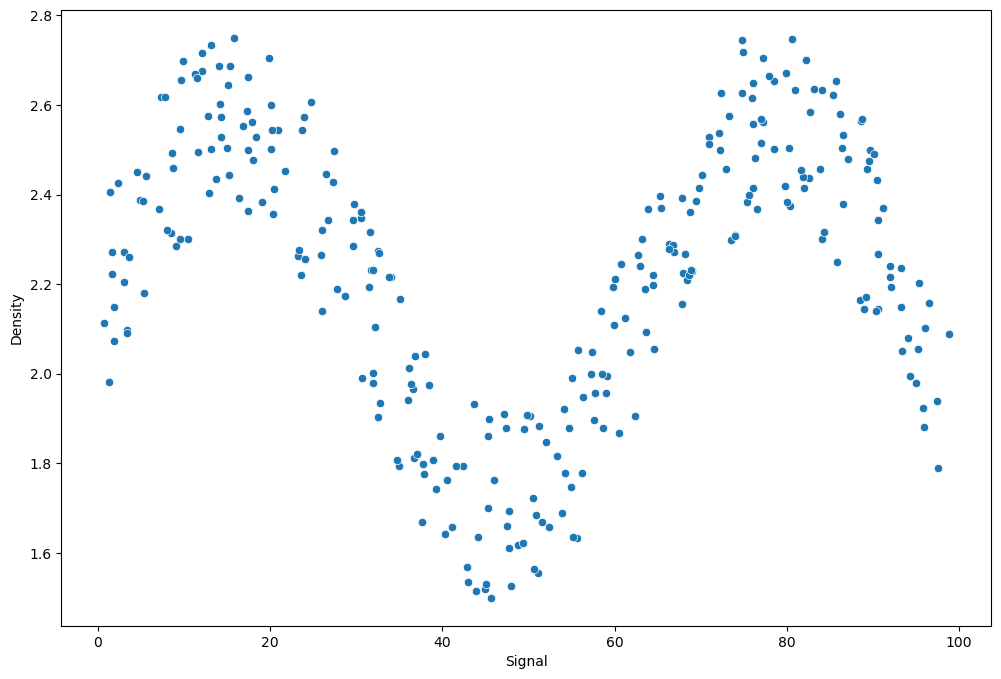

In [66]:
fig, ax = plt.subplots(figsize=(12,8))
sns.scatterplot(data=df, y='Density', x='Signal', ax=ax)

In [67]:
X = df['Signal'].values.reshape(-1, 1) # потому что одна колонка - это серия, а нам нужен двумерный массив


In [68]:
y = df['Density']

In [69]:
from sklearn.model_selection import train_test_split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [71]:
from sklearn.linear_model import LinearRegression

In [72]:
lr_model = LinearRegression()

In [73]:
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
lr_pred = lr_model.predict(X_test)


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [76]:
mean_absolute_error(y_test, lr_pred)

0.211198973318633

In [77]:
t = np.sqrt(mean_squared_error(y_test, lr_pred))

строим график для нашей модели

In [78]:
signal_range = np.arange(0, 100)
signal_preds = lr_model.predict(signal_range.reshape(-1, 1))

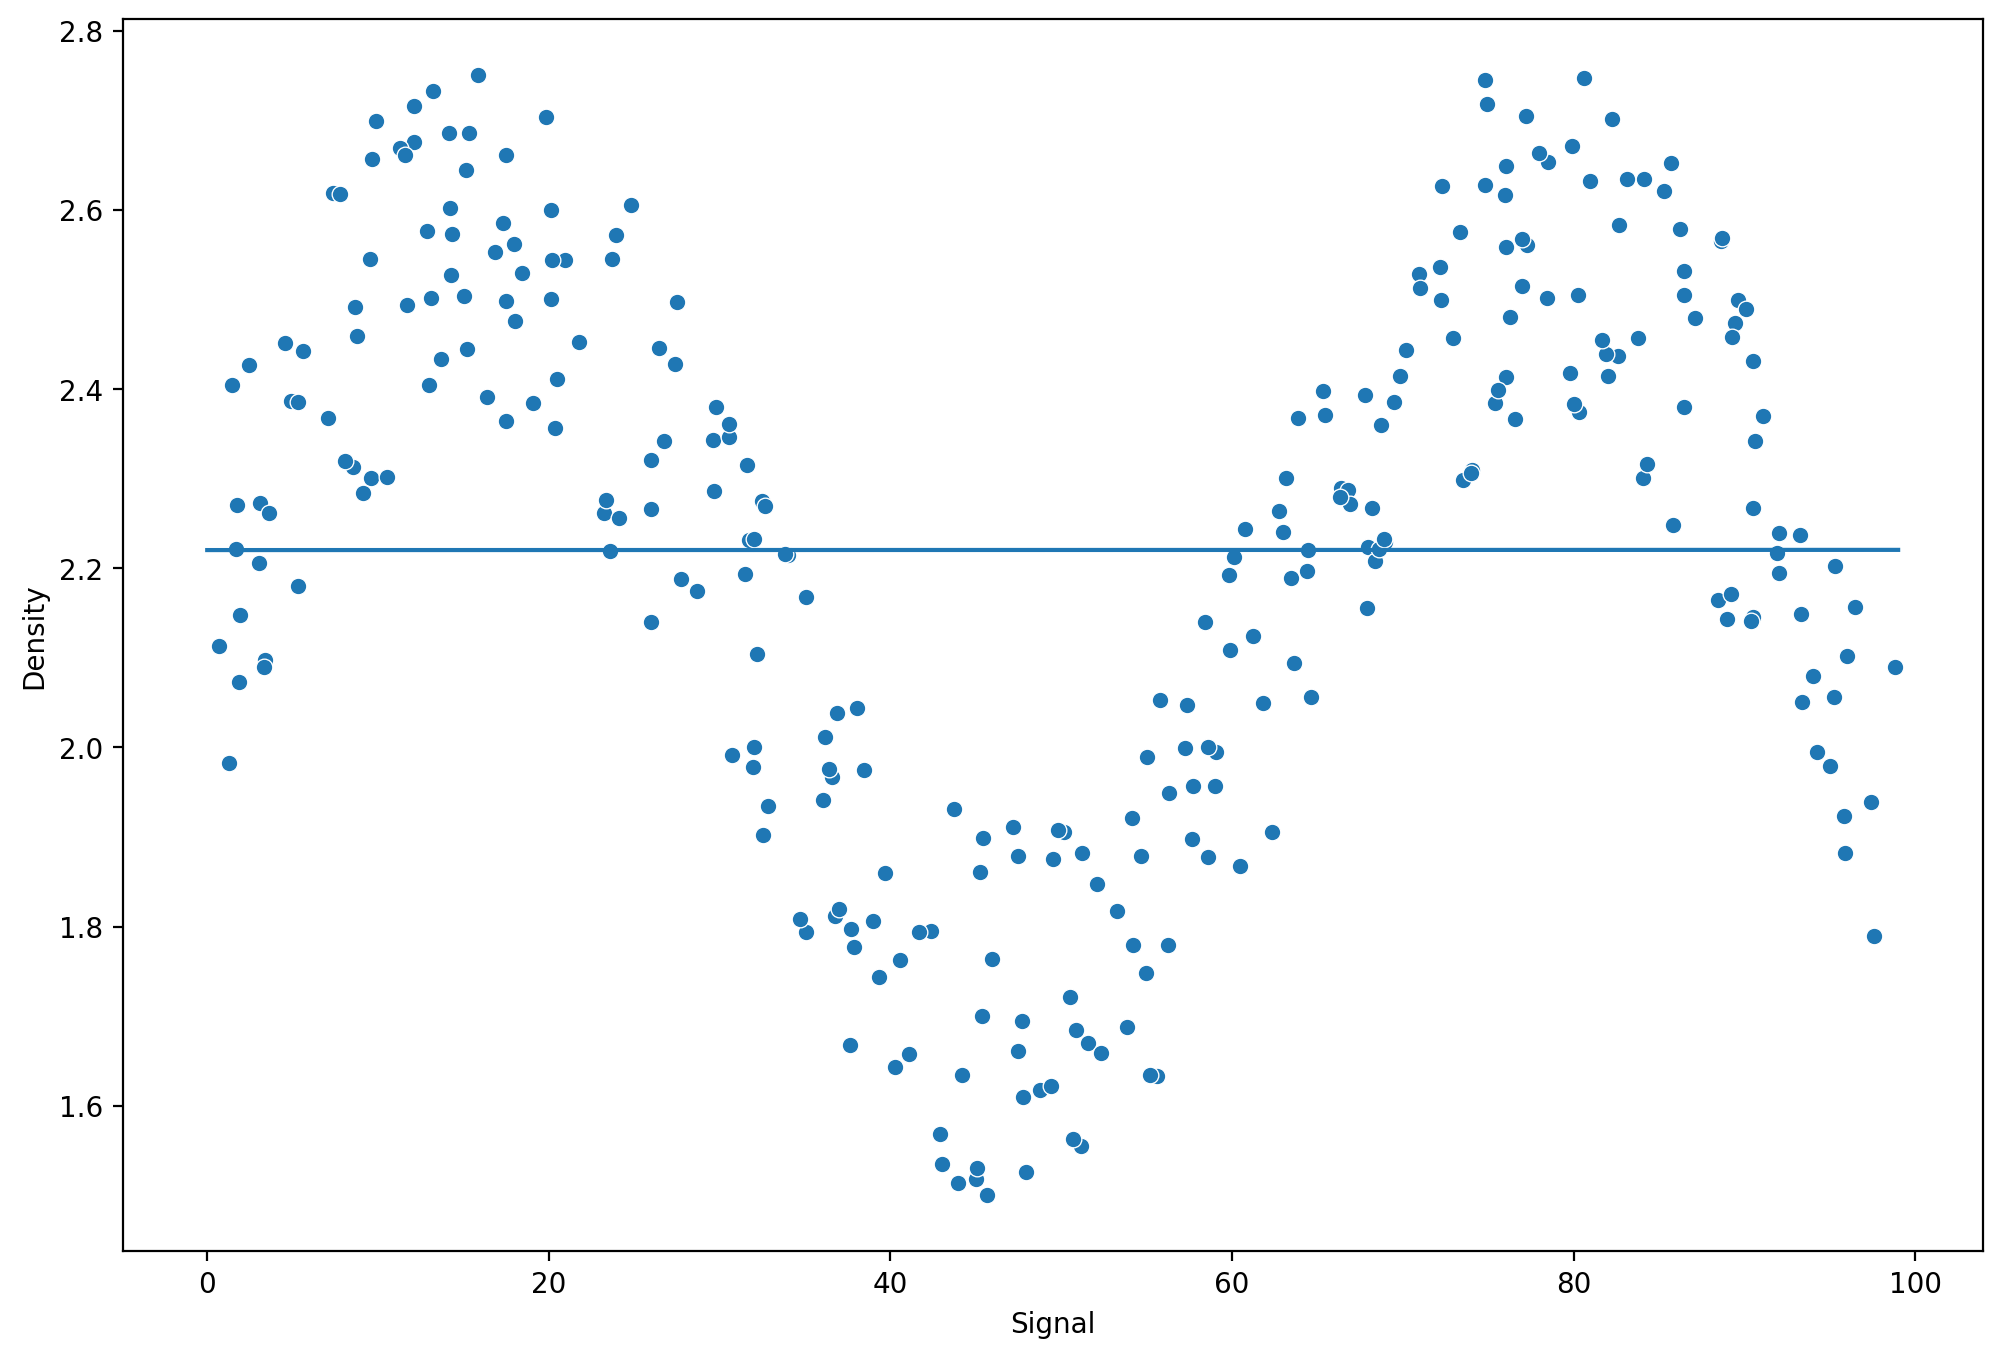

In [79]:
fig, ax = plt.subplots(figsize=(12,8), dpi=200)
sns.scatterplot(data=df, y='Density', x='Signal', ax=ax)
ax.plot(signal_range, signal_preds)

Полиномиальная регрессия

In [80]:
def run_model(model, X_train, y_train, X_test, y_test):
    # обучени модели
    model.fit(X_train, y_train)
    # вычисление метрики
    preds = model.predict(X_test)
    # Визуализация на график
    RMSE = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    print(f'RMSE: {RMSE}')
    print(f'MAE: {mae}')

    signal_range = np.arange(0, 100)
    signal_preds = model.predict(signal_range.reshape(-1, 1))
    
    fig, ax = plt.subplots(figsize=(12,8), dpi=200)
    sns.scatterplot(data=df, y='Density', x='Signal', ax=ax)
    ax.plot(signal_range, signal_preds, color='black', lw=2)

RMSE: 0.2570051996584629
MAE: 0.211198973318633


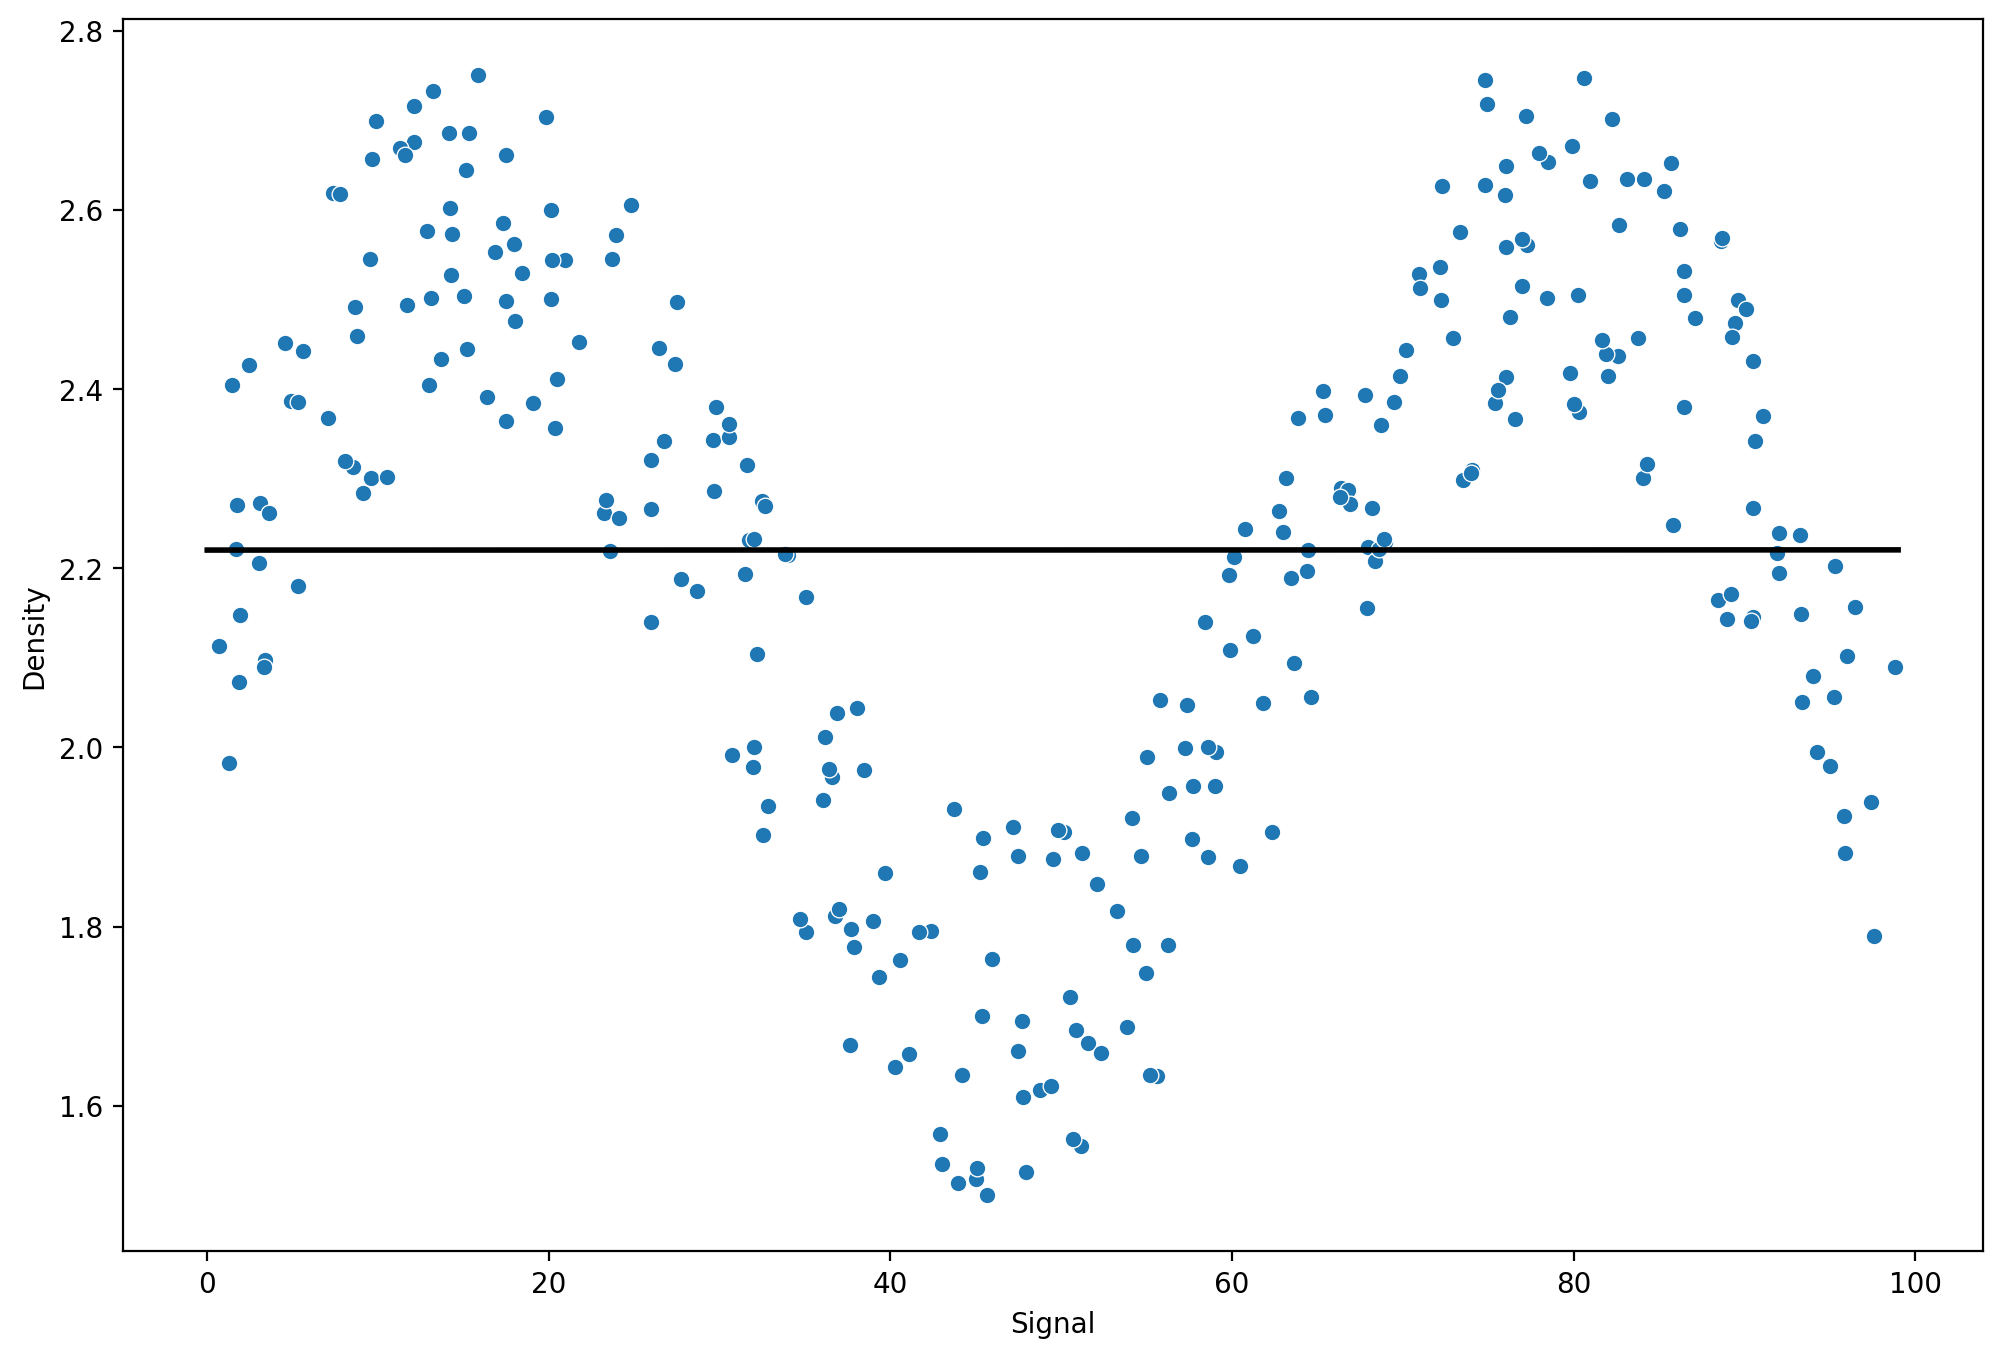

In [81]:
model = LinearRegression()

run_model(model, X_train, y_train, X_test, y_test)

In [82]:
from sklearn.pipeline import make_pipeline

In [83]:
from sklearn.preprocessing import PolynomialFeatures

RMSE: 0.13526449369797783
MAE: 0.11916583142343974


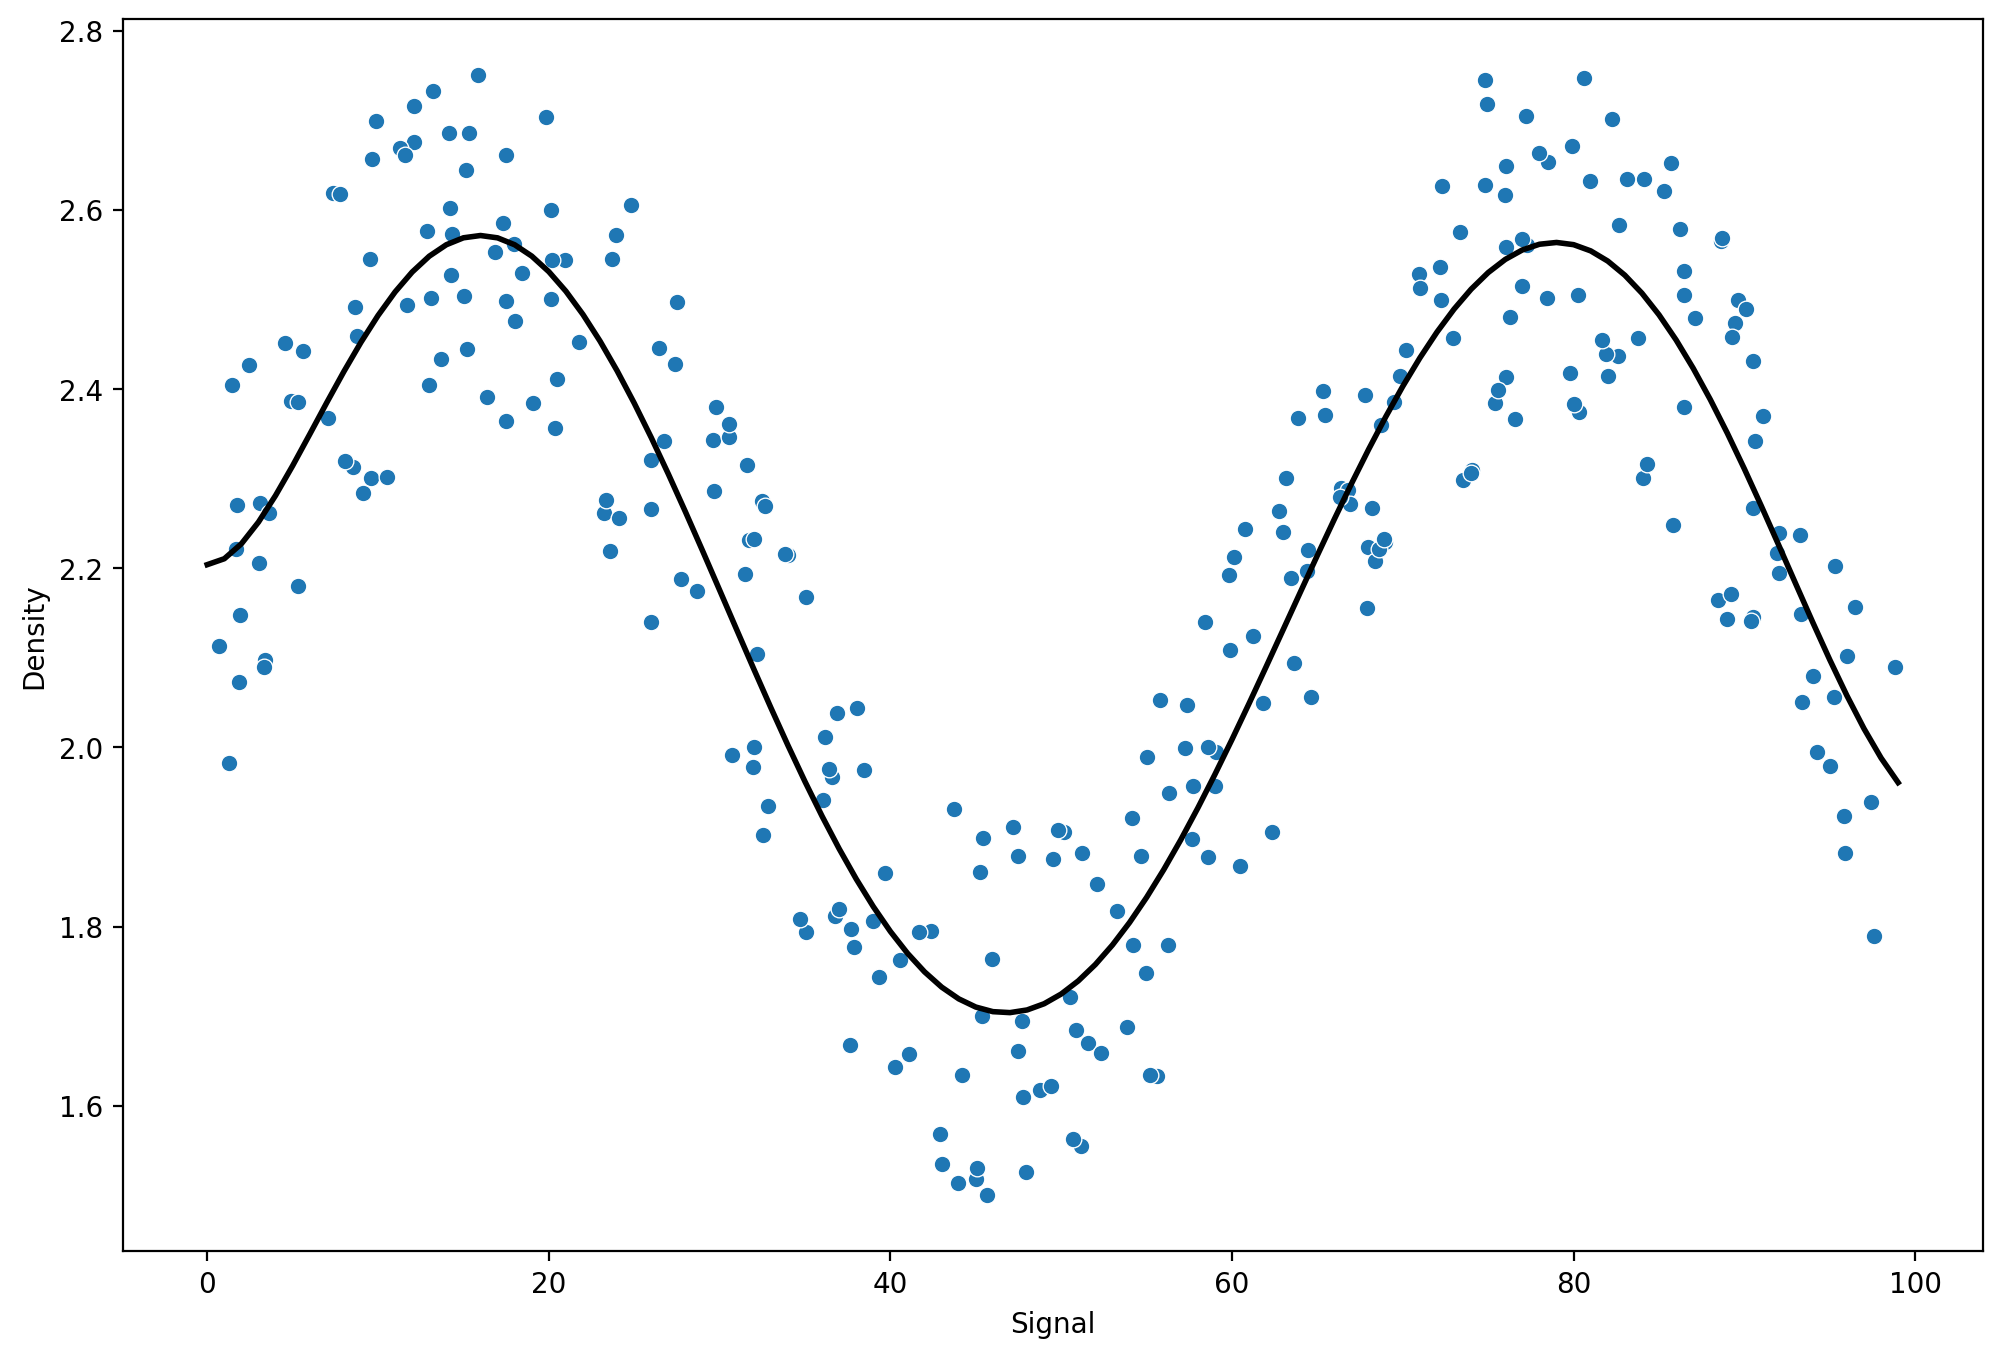

In [84]:
pipe = make_pipeline(PolynomialFeatures(degree=7), LinearRegression())  # указываем действия

run_model(pipe, X_train, y_train, X_test, y_test)

In [85]:
from sklearn.neighbors import KNeighborsRegressor

RMSE: 0.1523487028635337
MAE: 0.11877297474442378
RMSE: 0.13730685016923647
MAE: 0.12198383614100558
RMSE: 0.13277855732740926
MAE: 0.11635971693292672
RMSE: 0.1397499127378895
MAE: 0.1207030971917154
RMSE: 0.15954234753677107
MAE: 0.13363165935705318


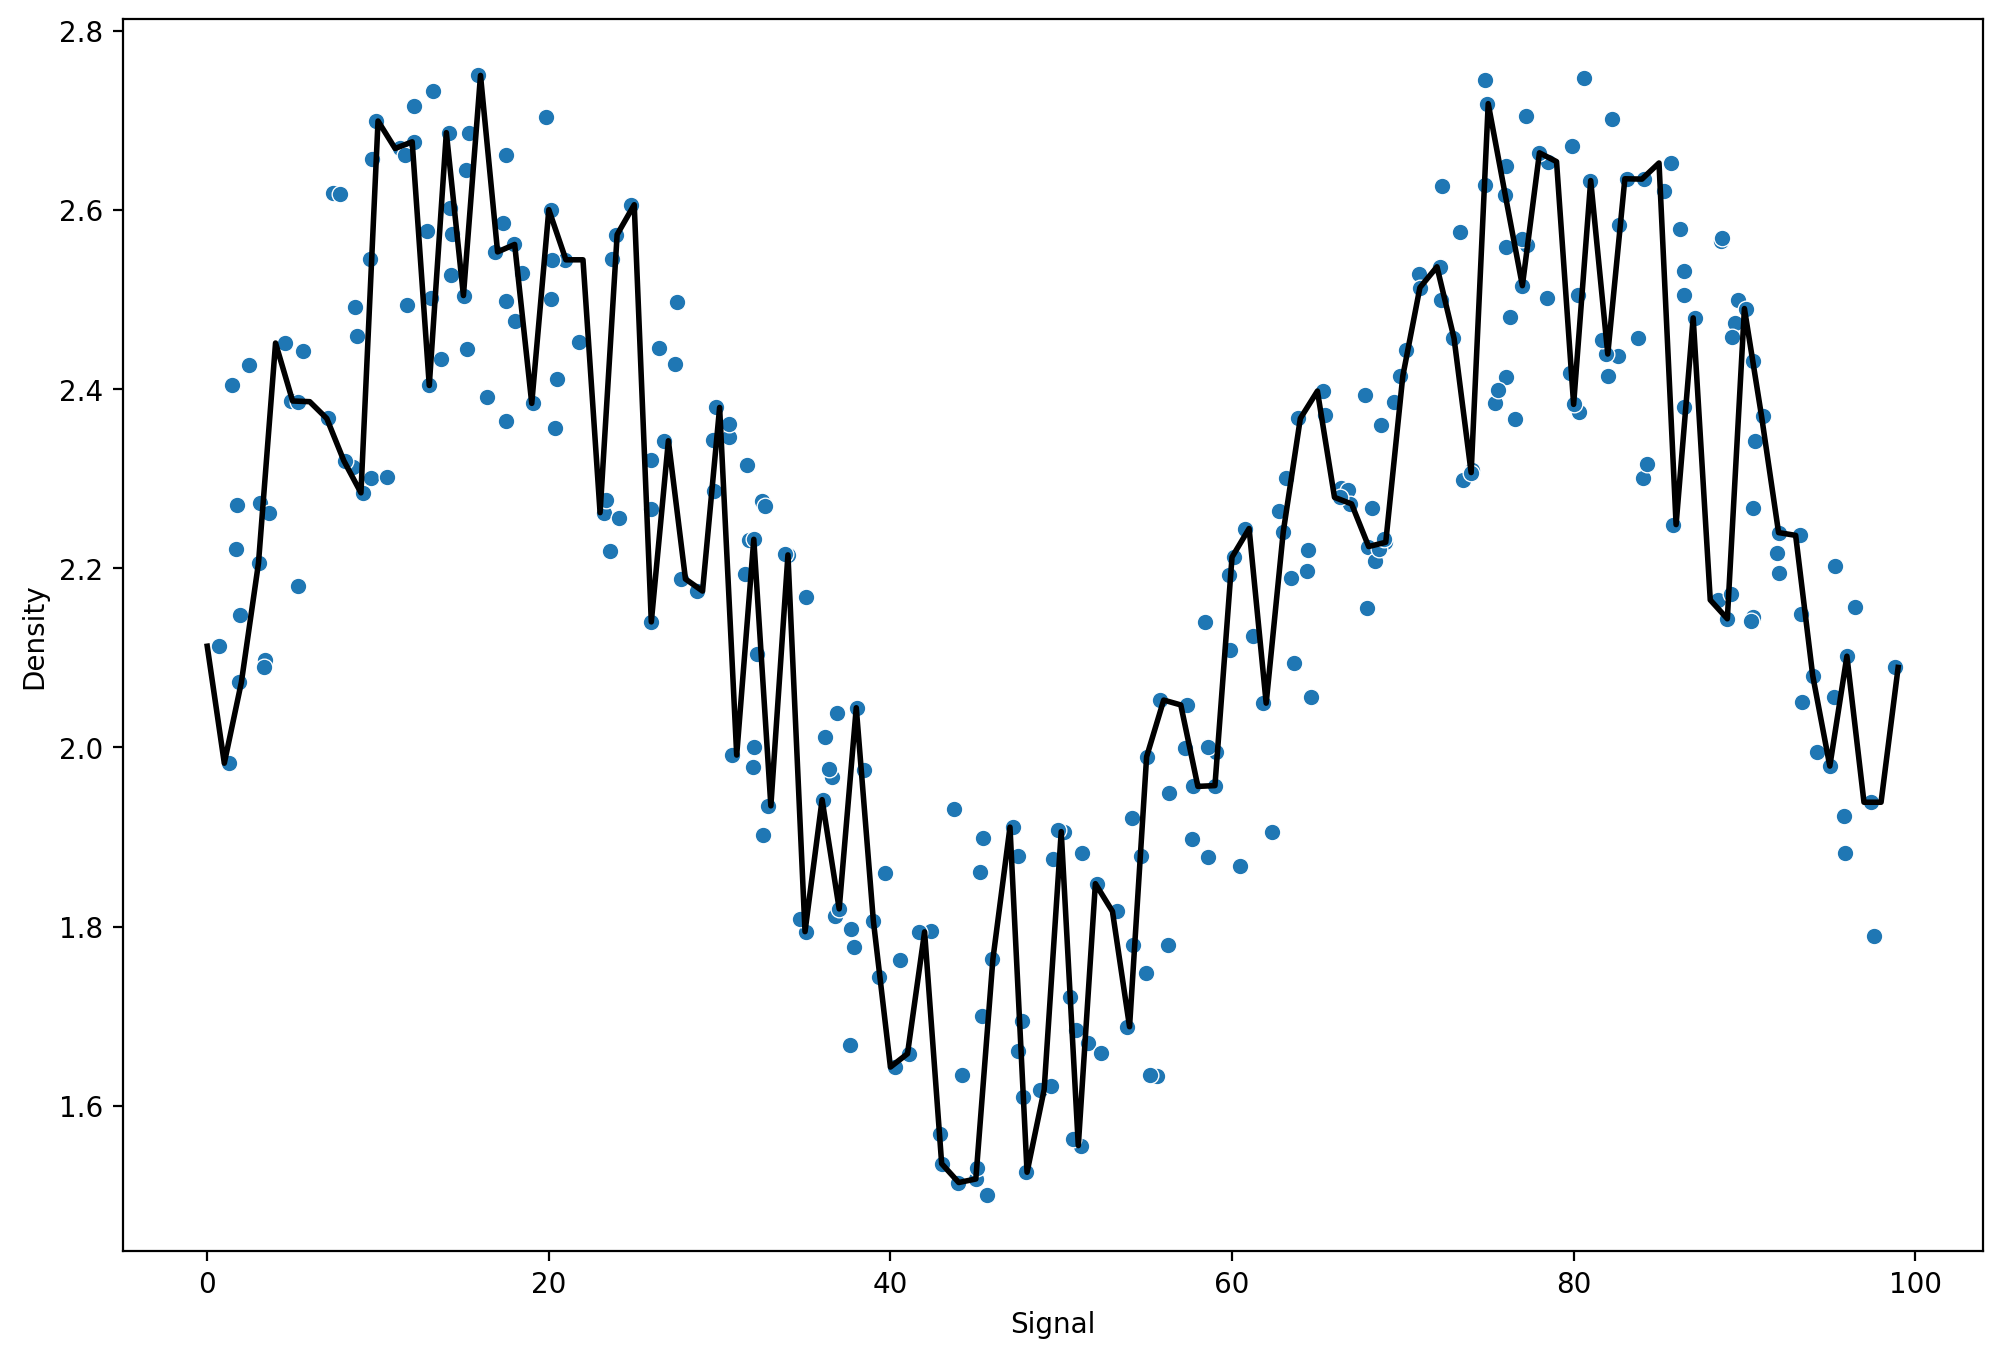

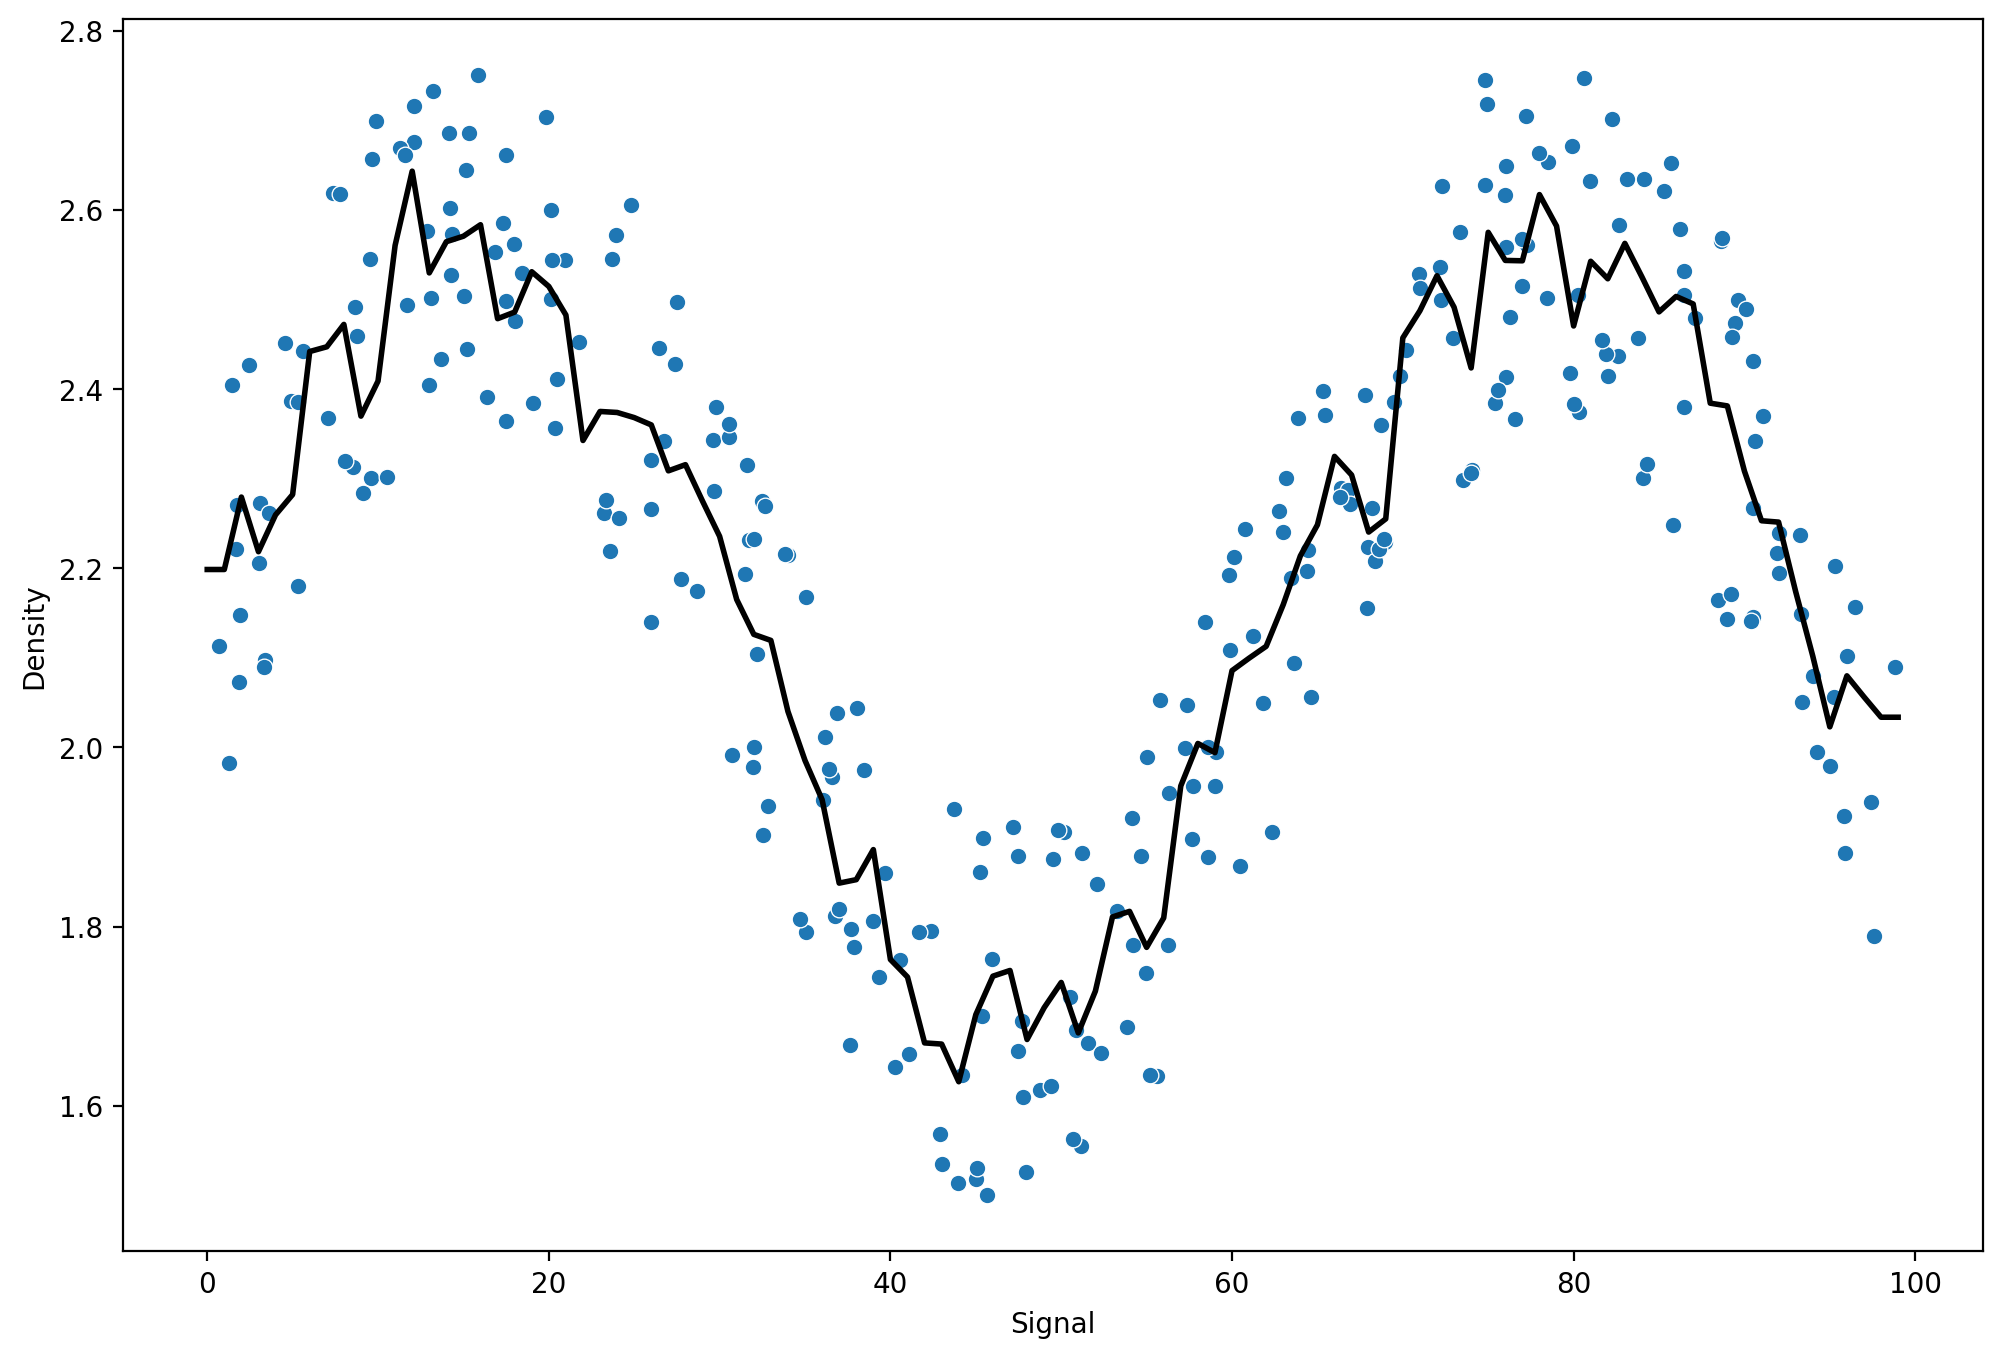

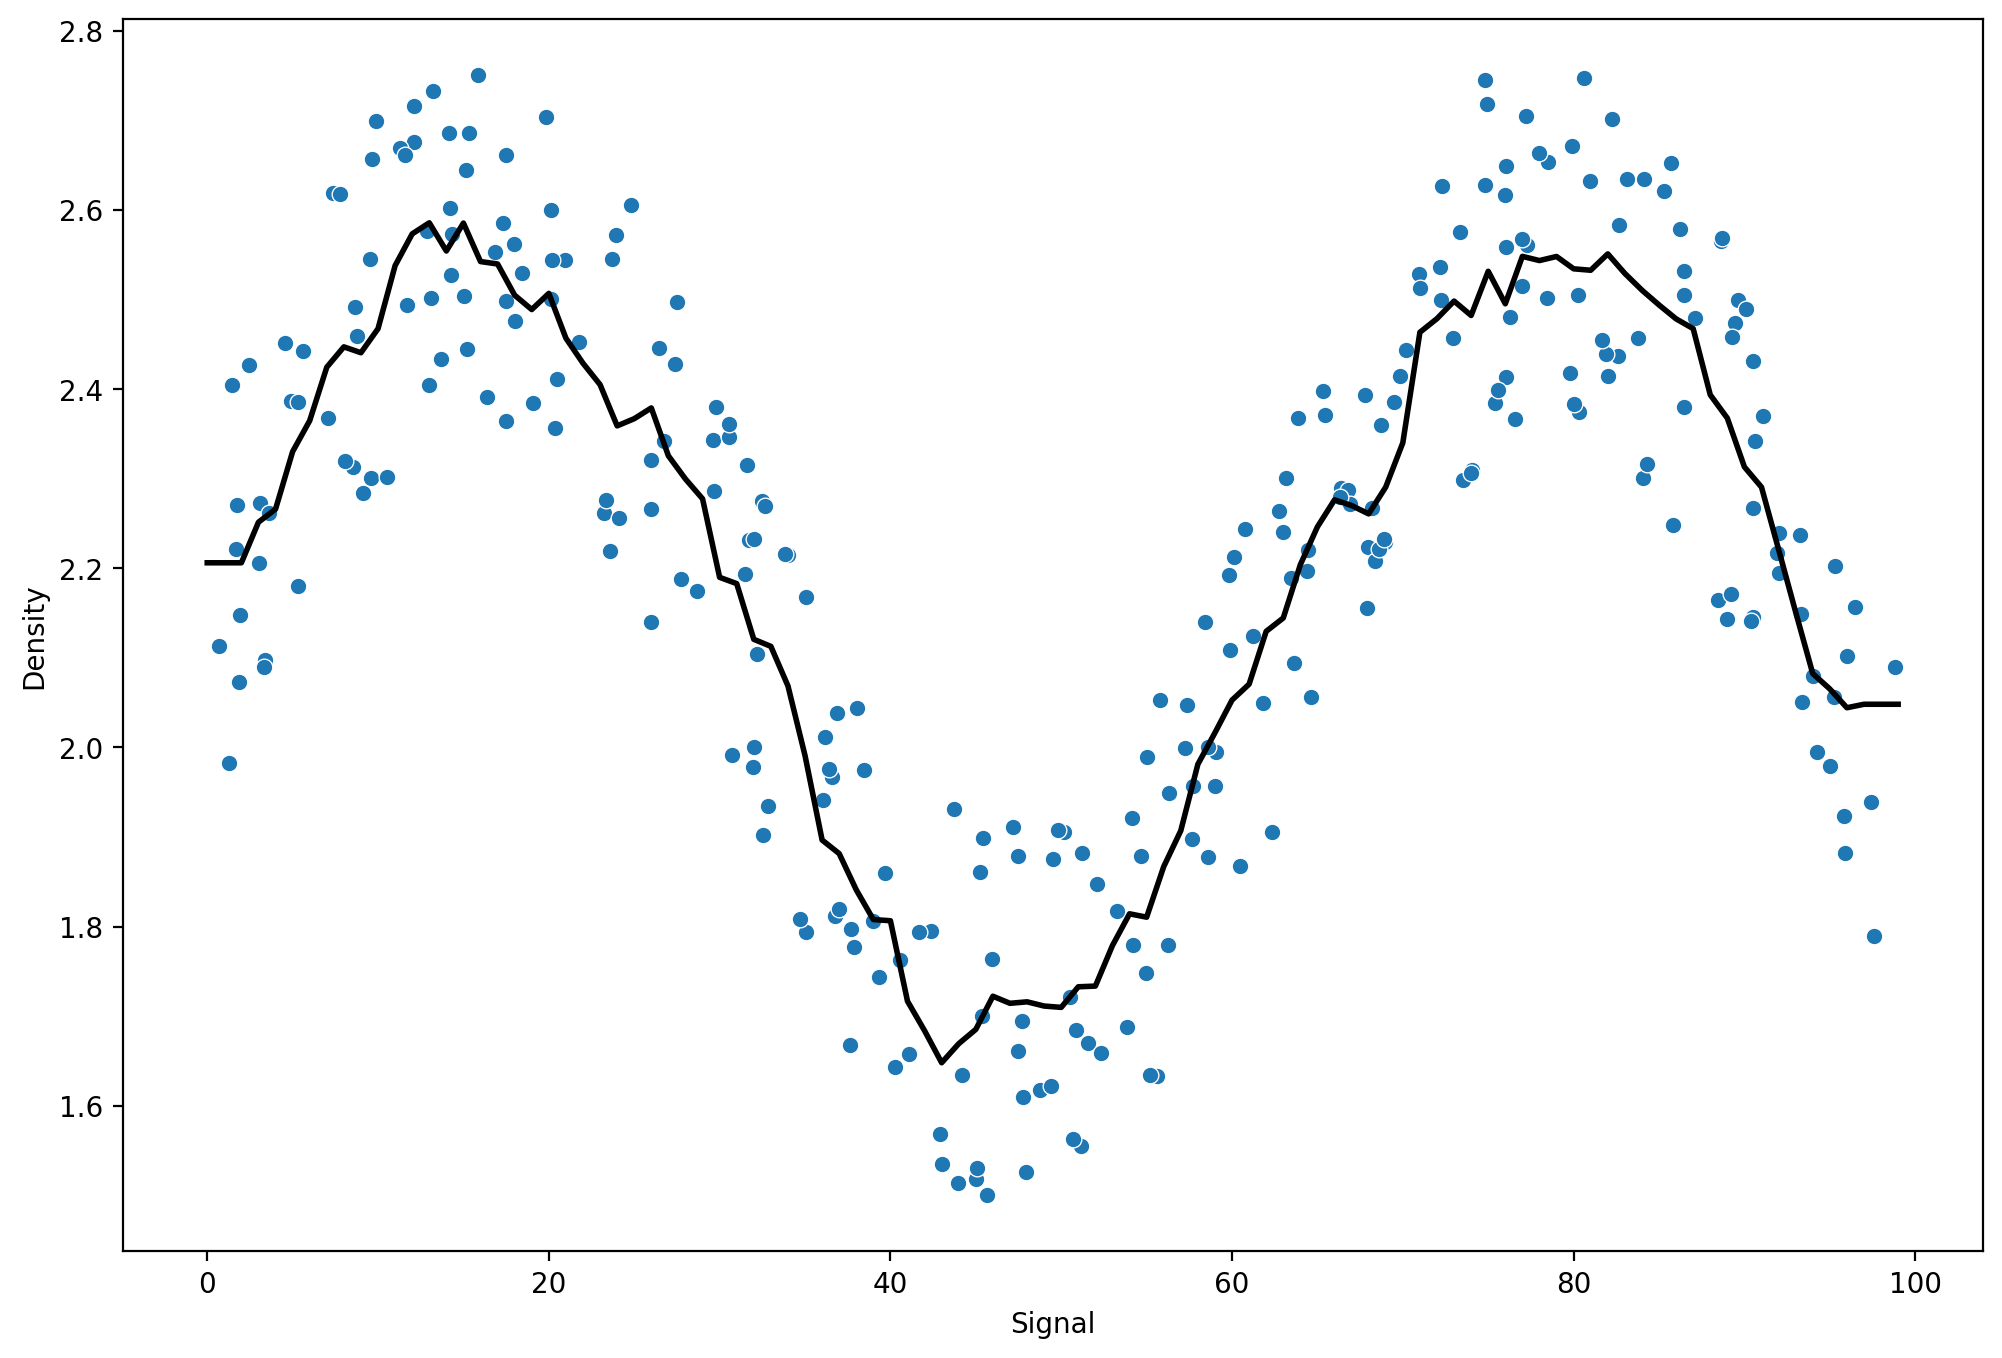

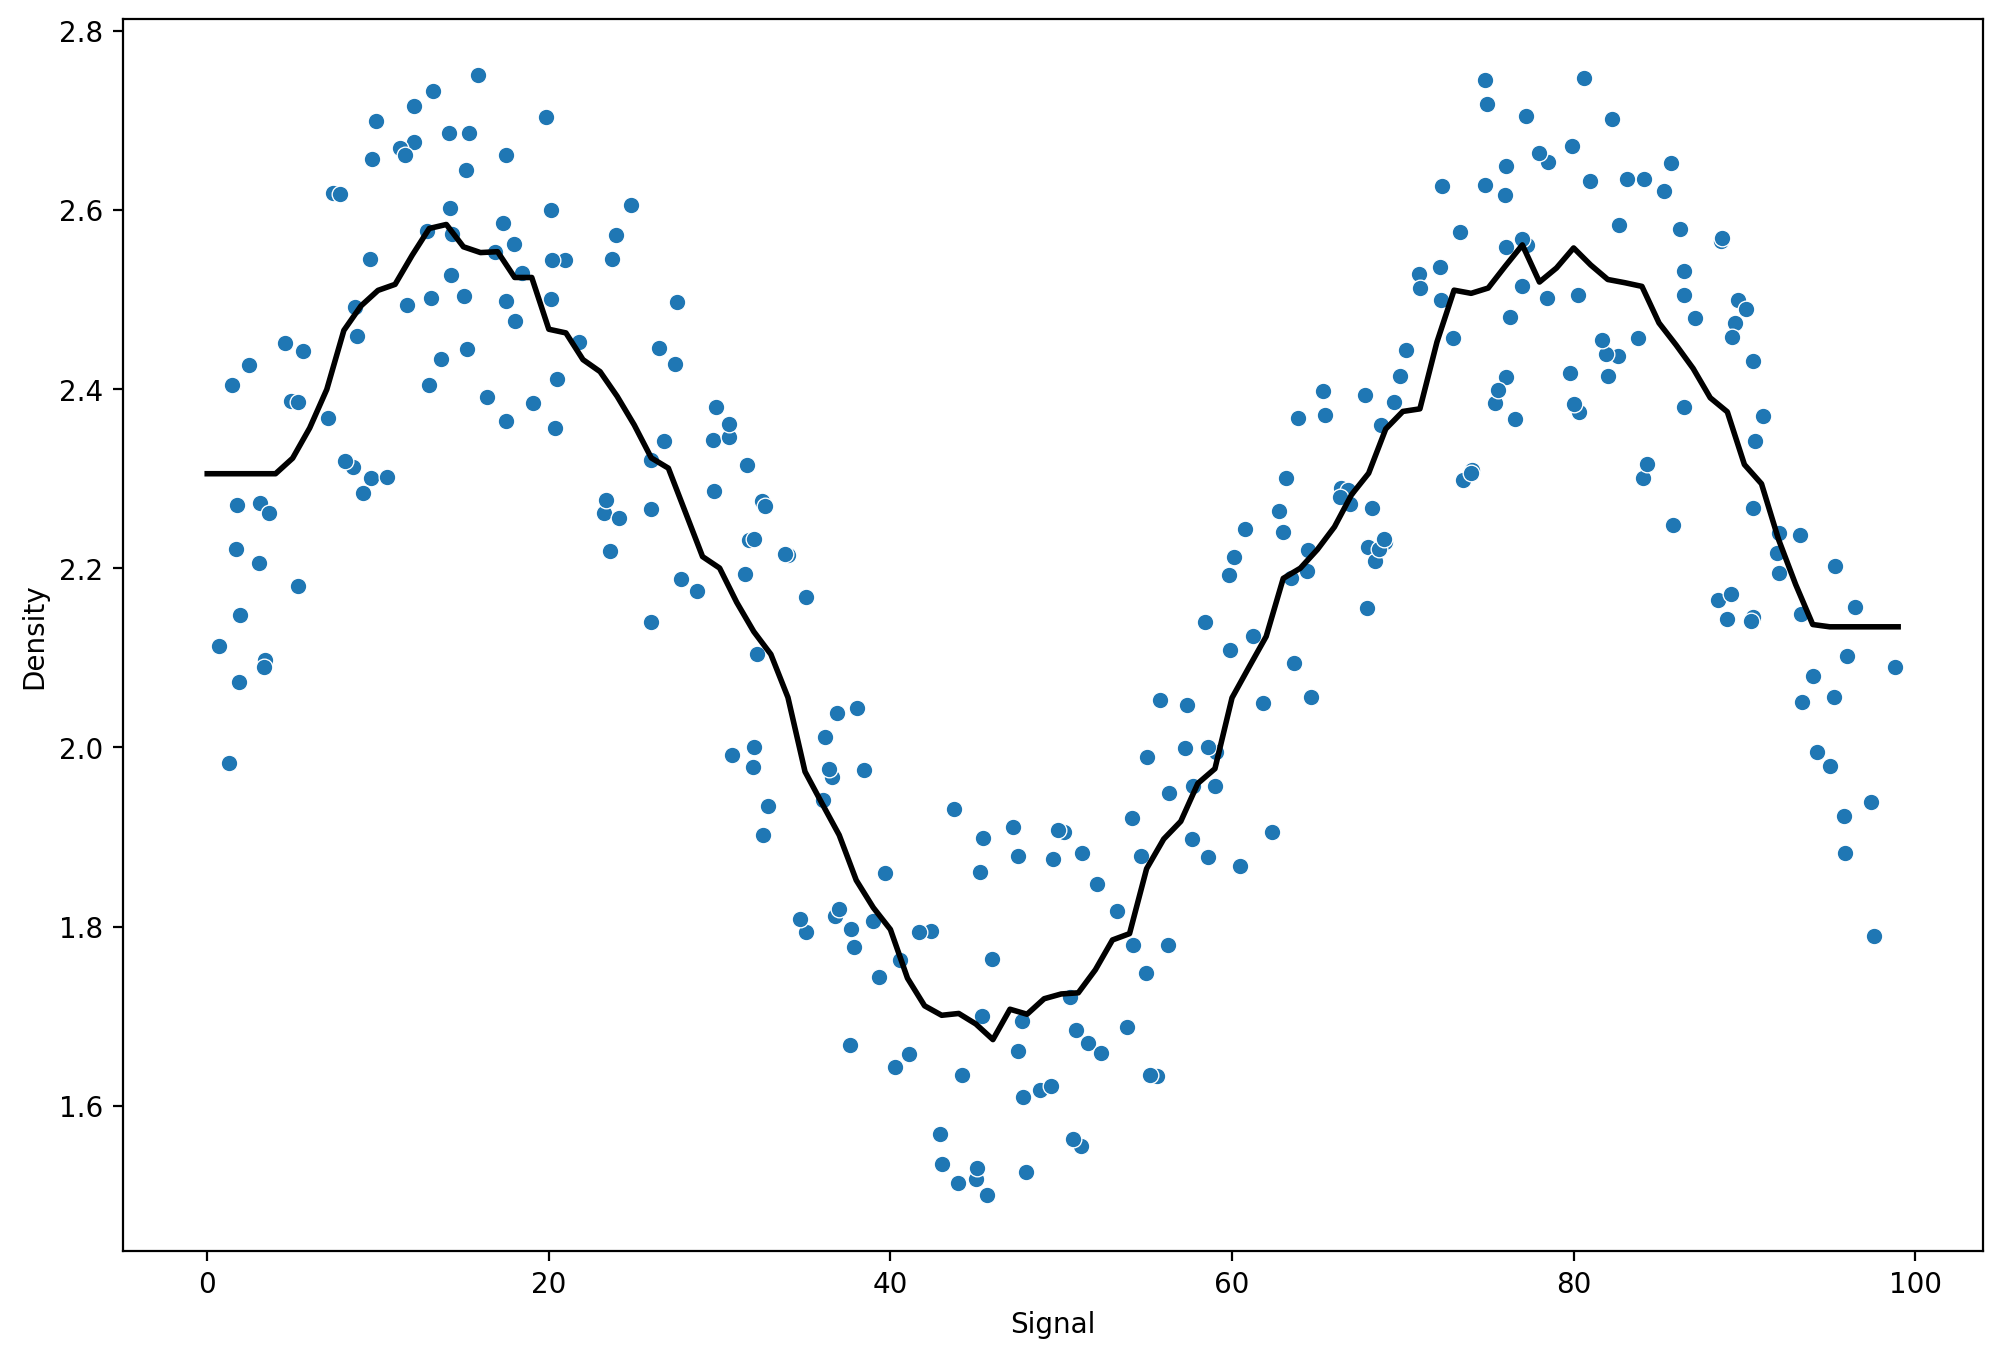

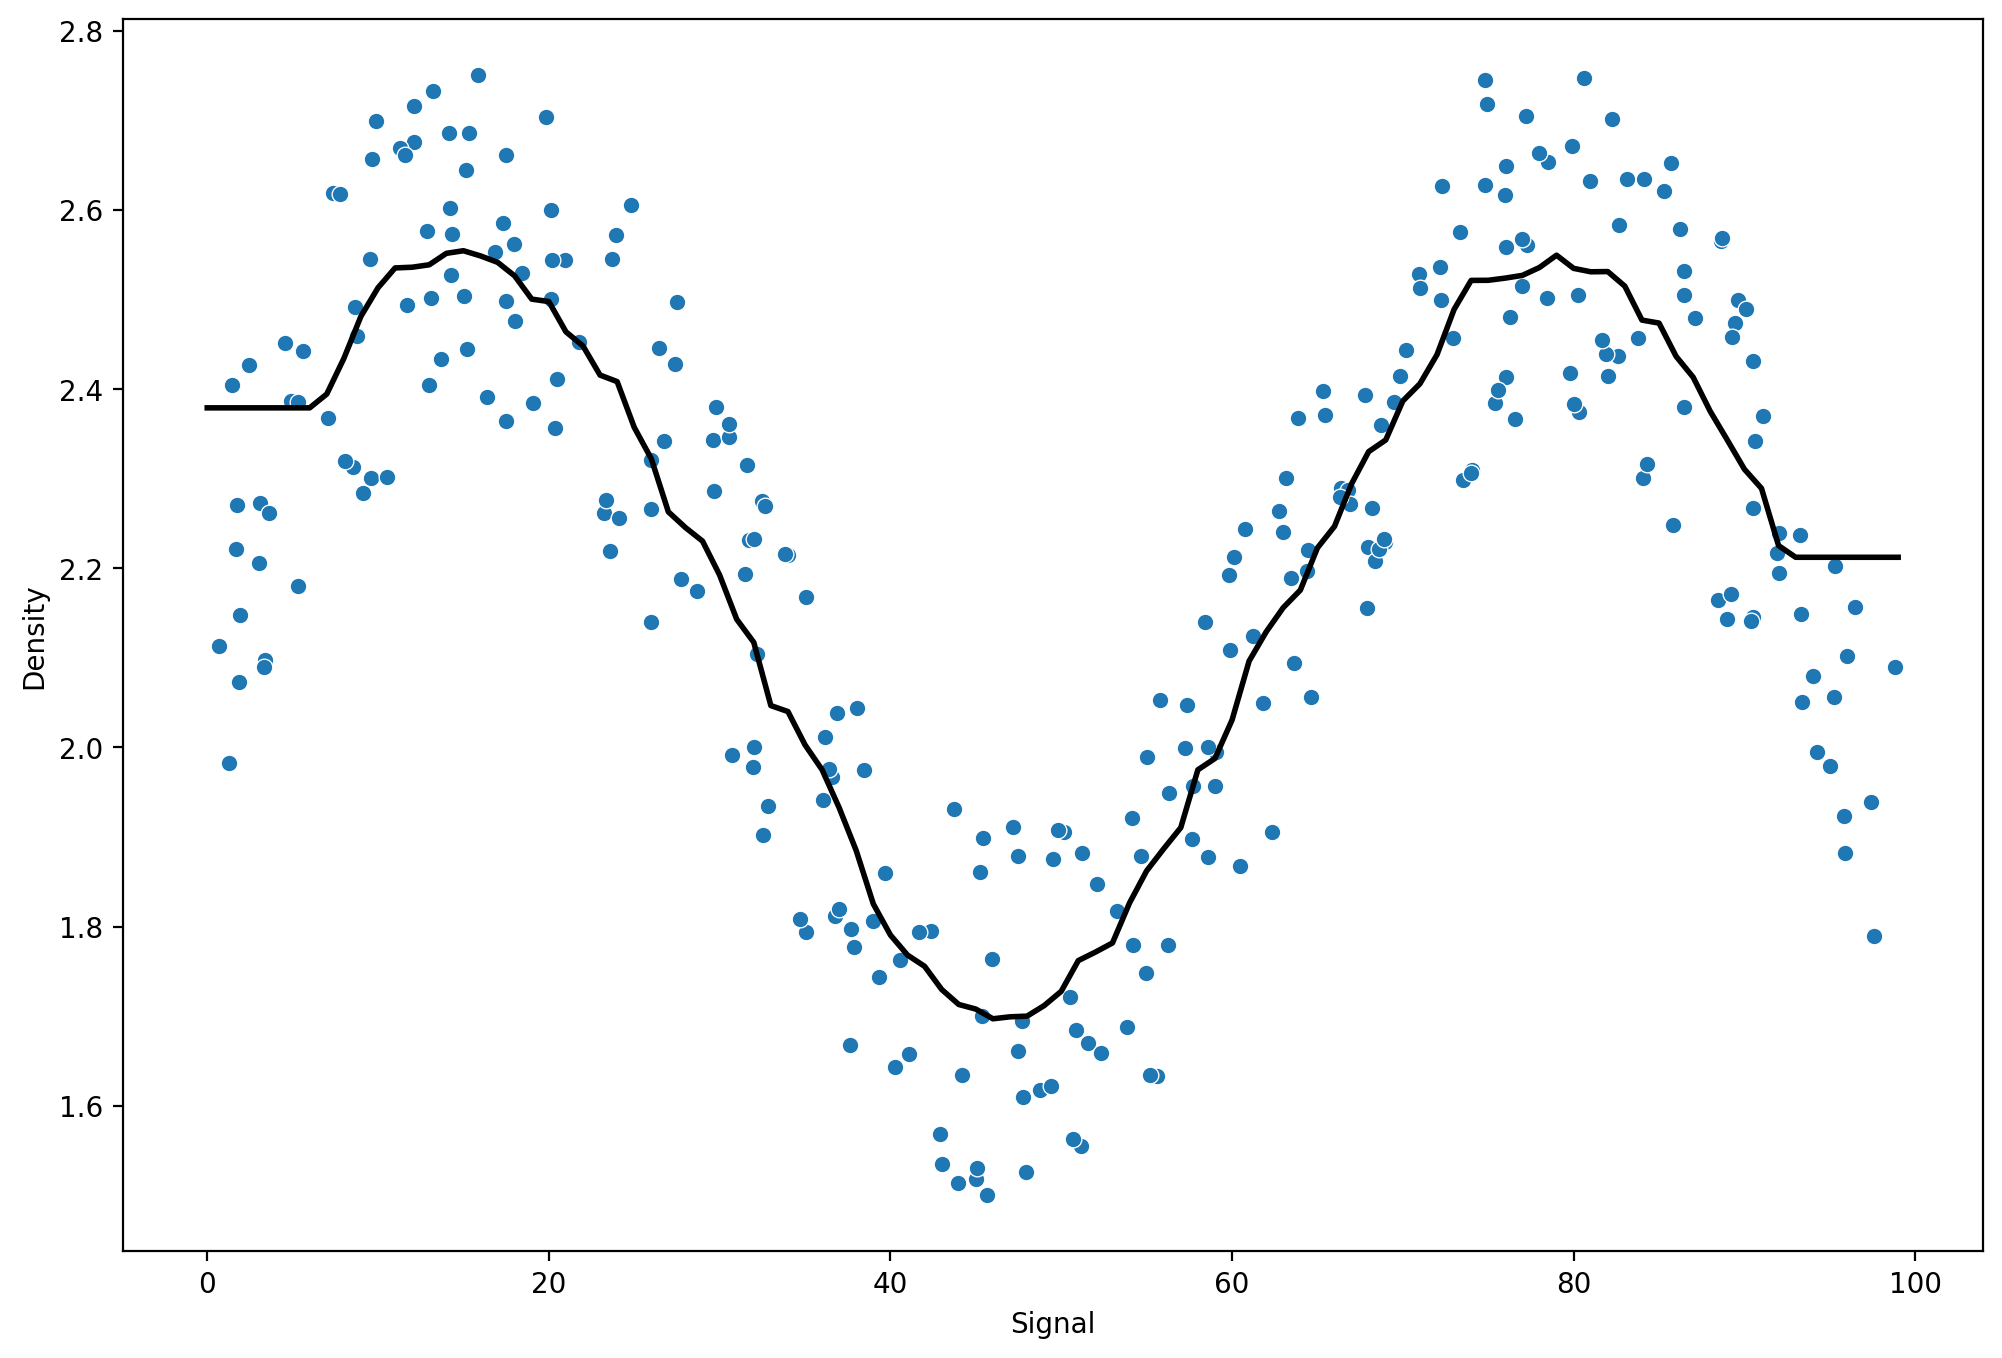

In [86]:
k_values = [1, 5, 10, 20, 30]

for n in k_values:
    model = KNeighborsRegressor(n_neighbors=n)
    run_model(model, X_train, y_train, X_test, y_test)

RMSE: 0.1523487028635337
MAE: 0.11877297474442378


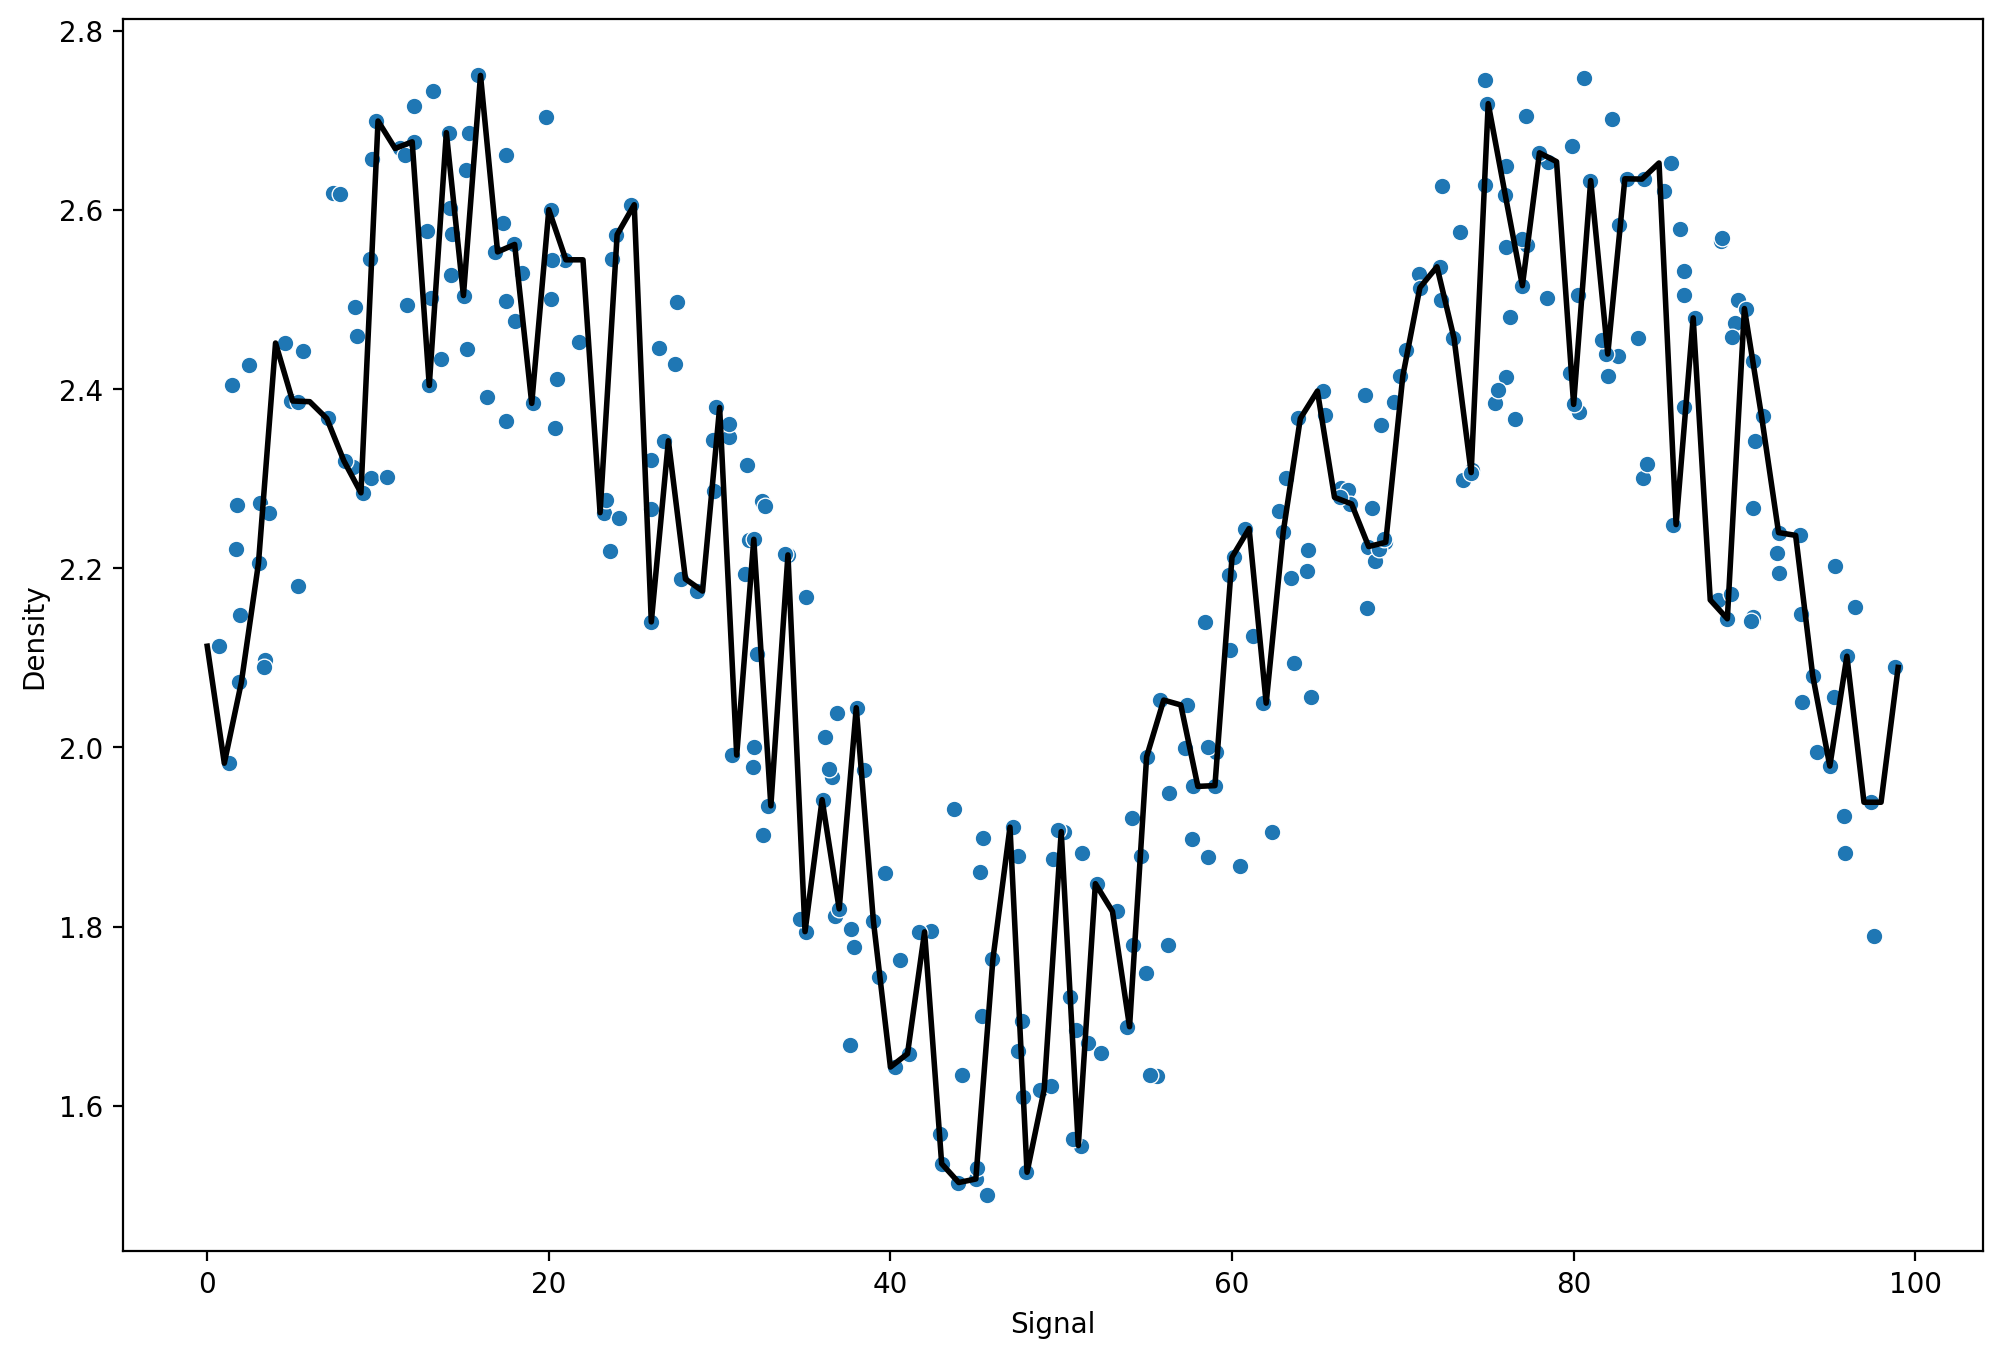

In [87]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
run_model(model, X_train, y_train, X_test, y_test)

In [89]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV


RMSE: 0.13015742723601528
MAE: 0.11243103141068958


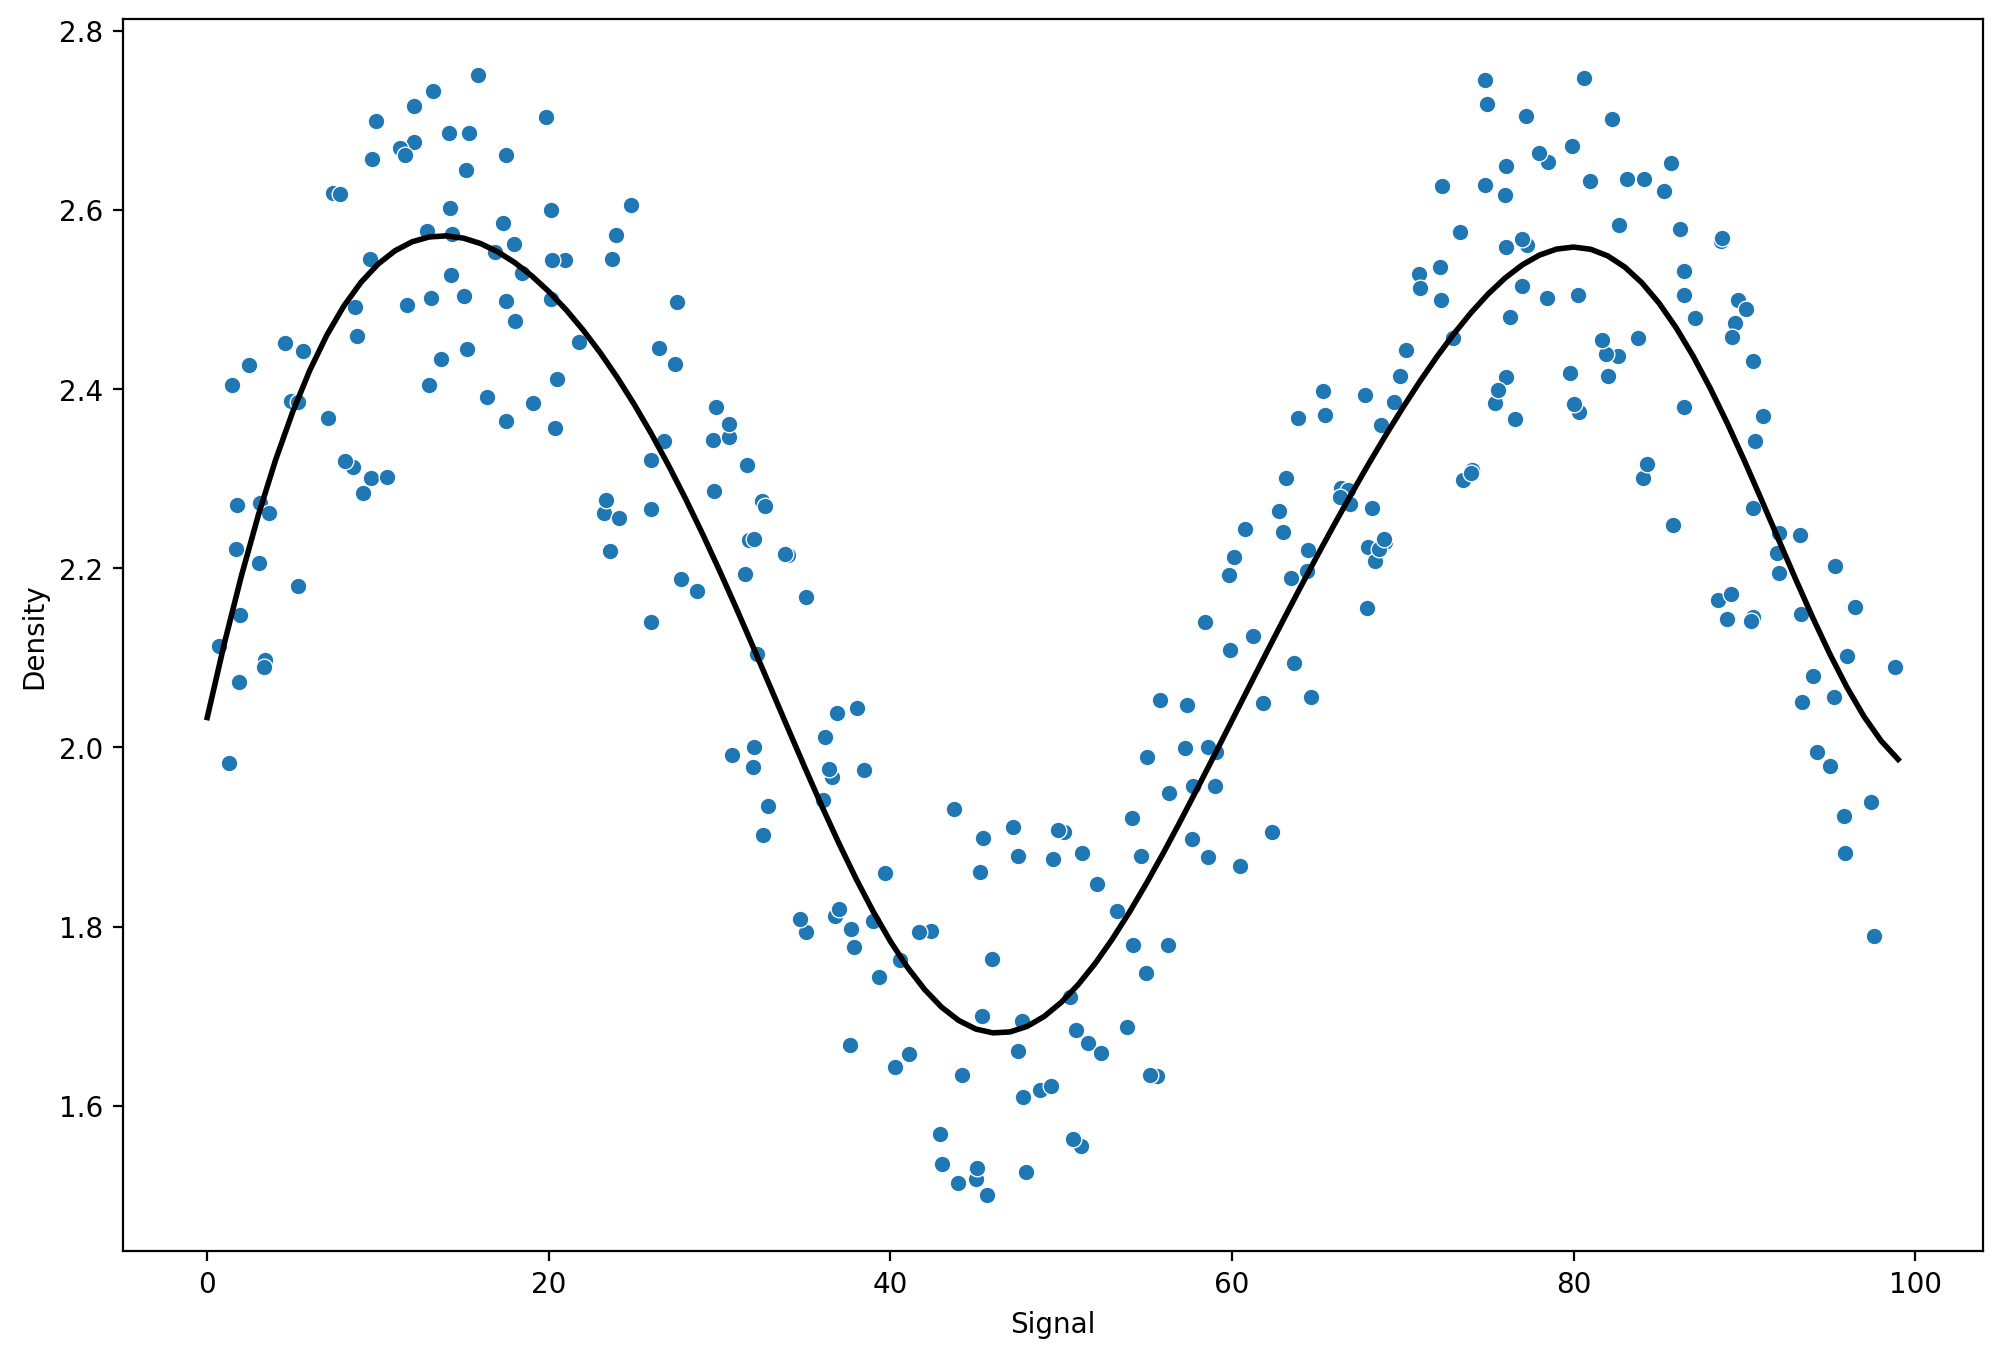

In [91]:
svr = SVR()
param_grid = {
    'C': [0.01, 0.1, 1, 5, 10, 100],
    'gamma': ['auto', 'scale']
}

grid = GridSearchCV(svr, param_grid)
run_model(grid, X_train, y_train, X_test, y_test)

RMSE: 0.13251181149686464
MAE: 0.1114681309893937


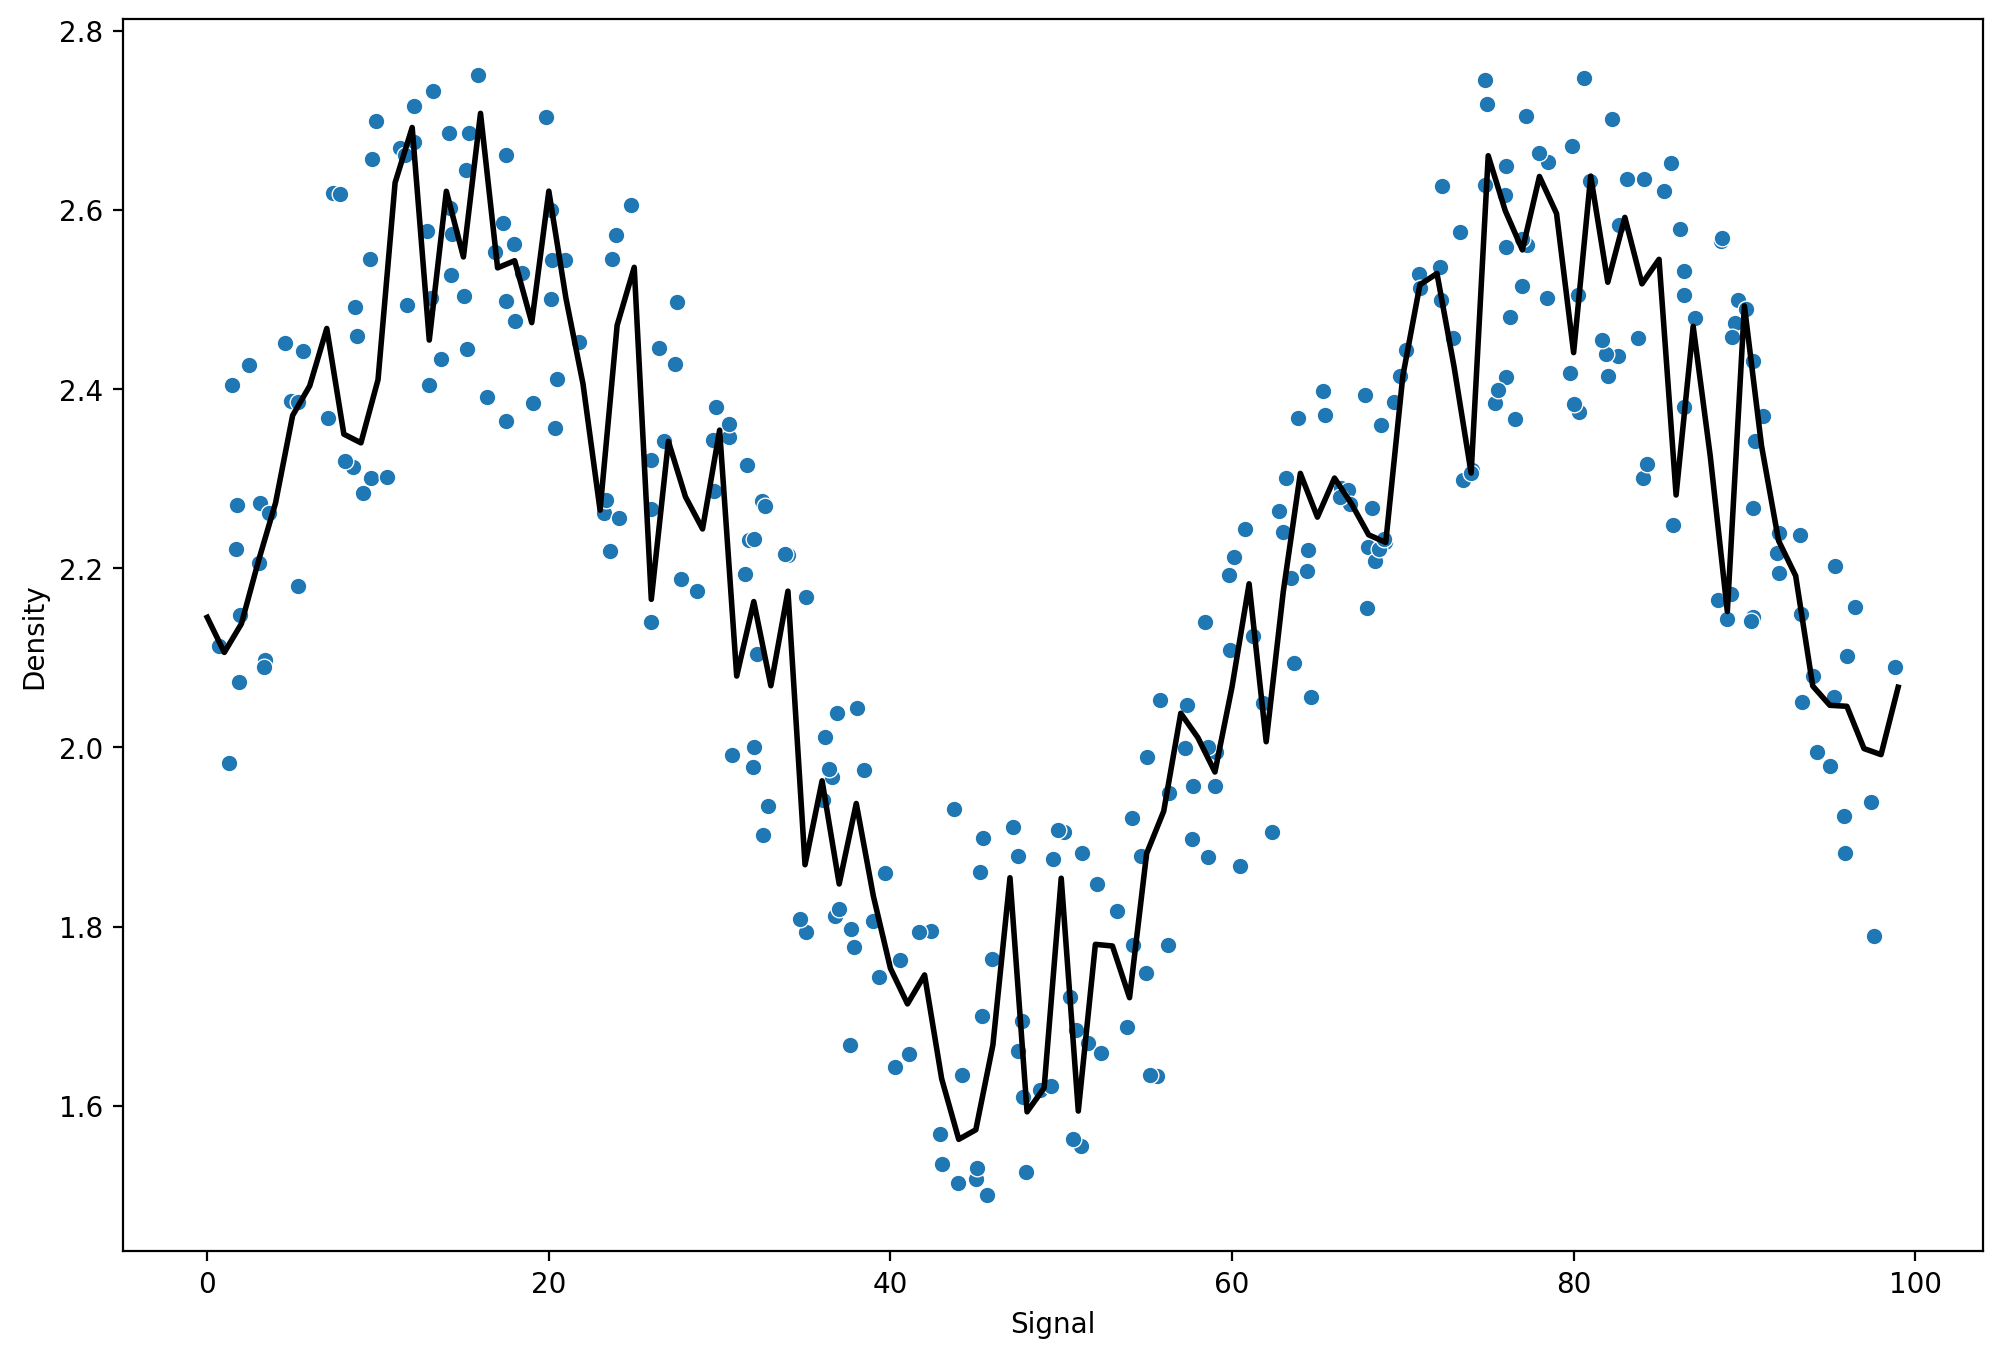

In [95]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=10)
run_model(rfr, X_train, y_train, X_test, y_test)

In [96]:
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor

RMSE: 0.13294148649584667
MAE: 0.11318284854800689


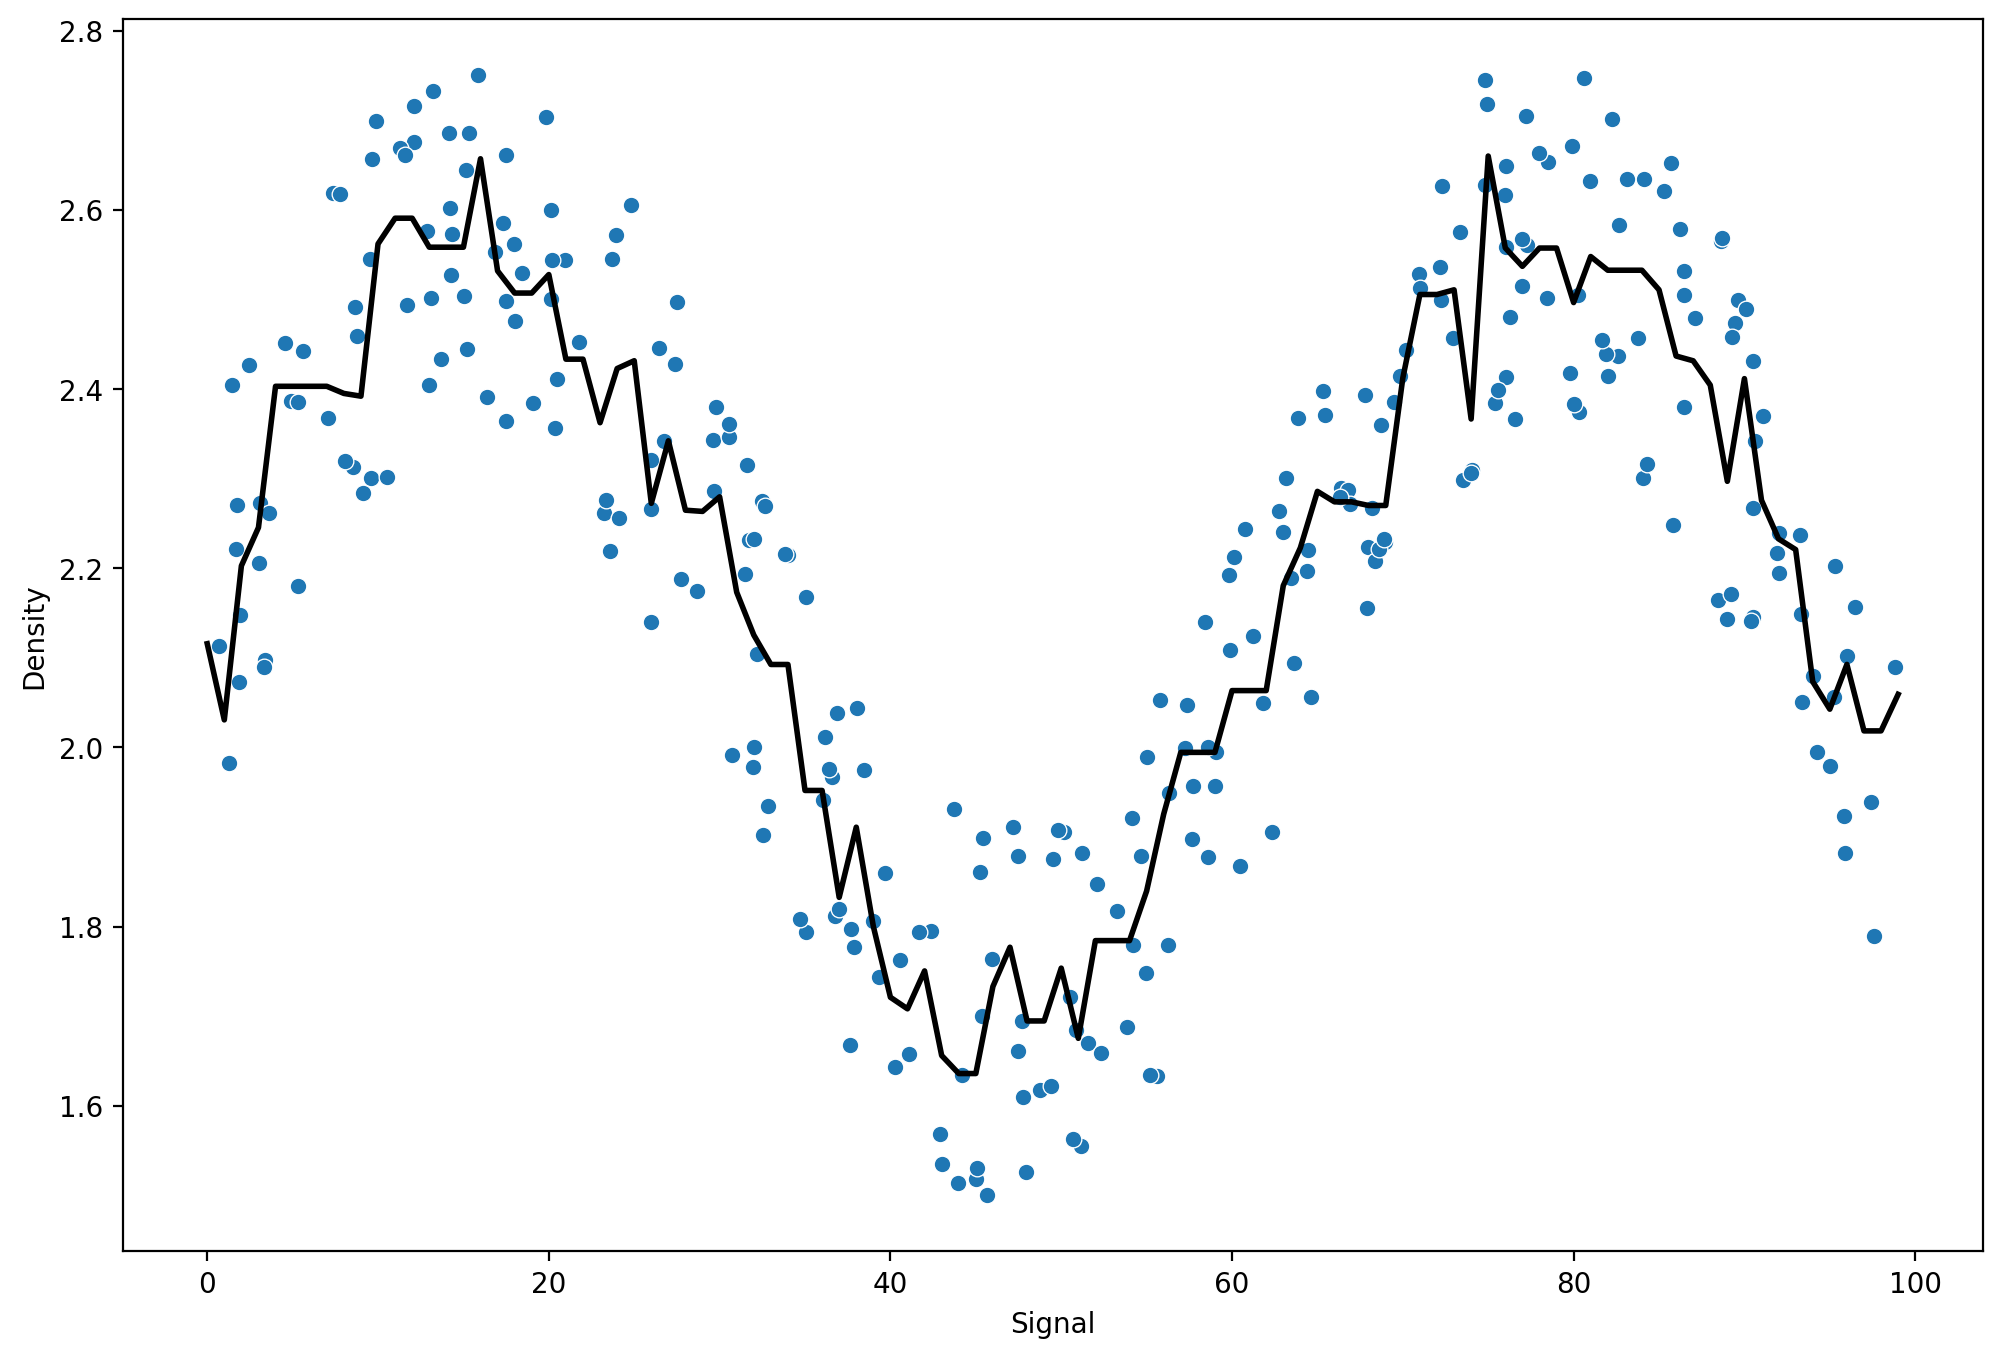

In [97]:
model = GradientBoostingRegressor()
run_model(model, X_train, y_train, X_test, y_test)

RMSE: 0.1379267416136477
MAE: 0.11816655713804478


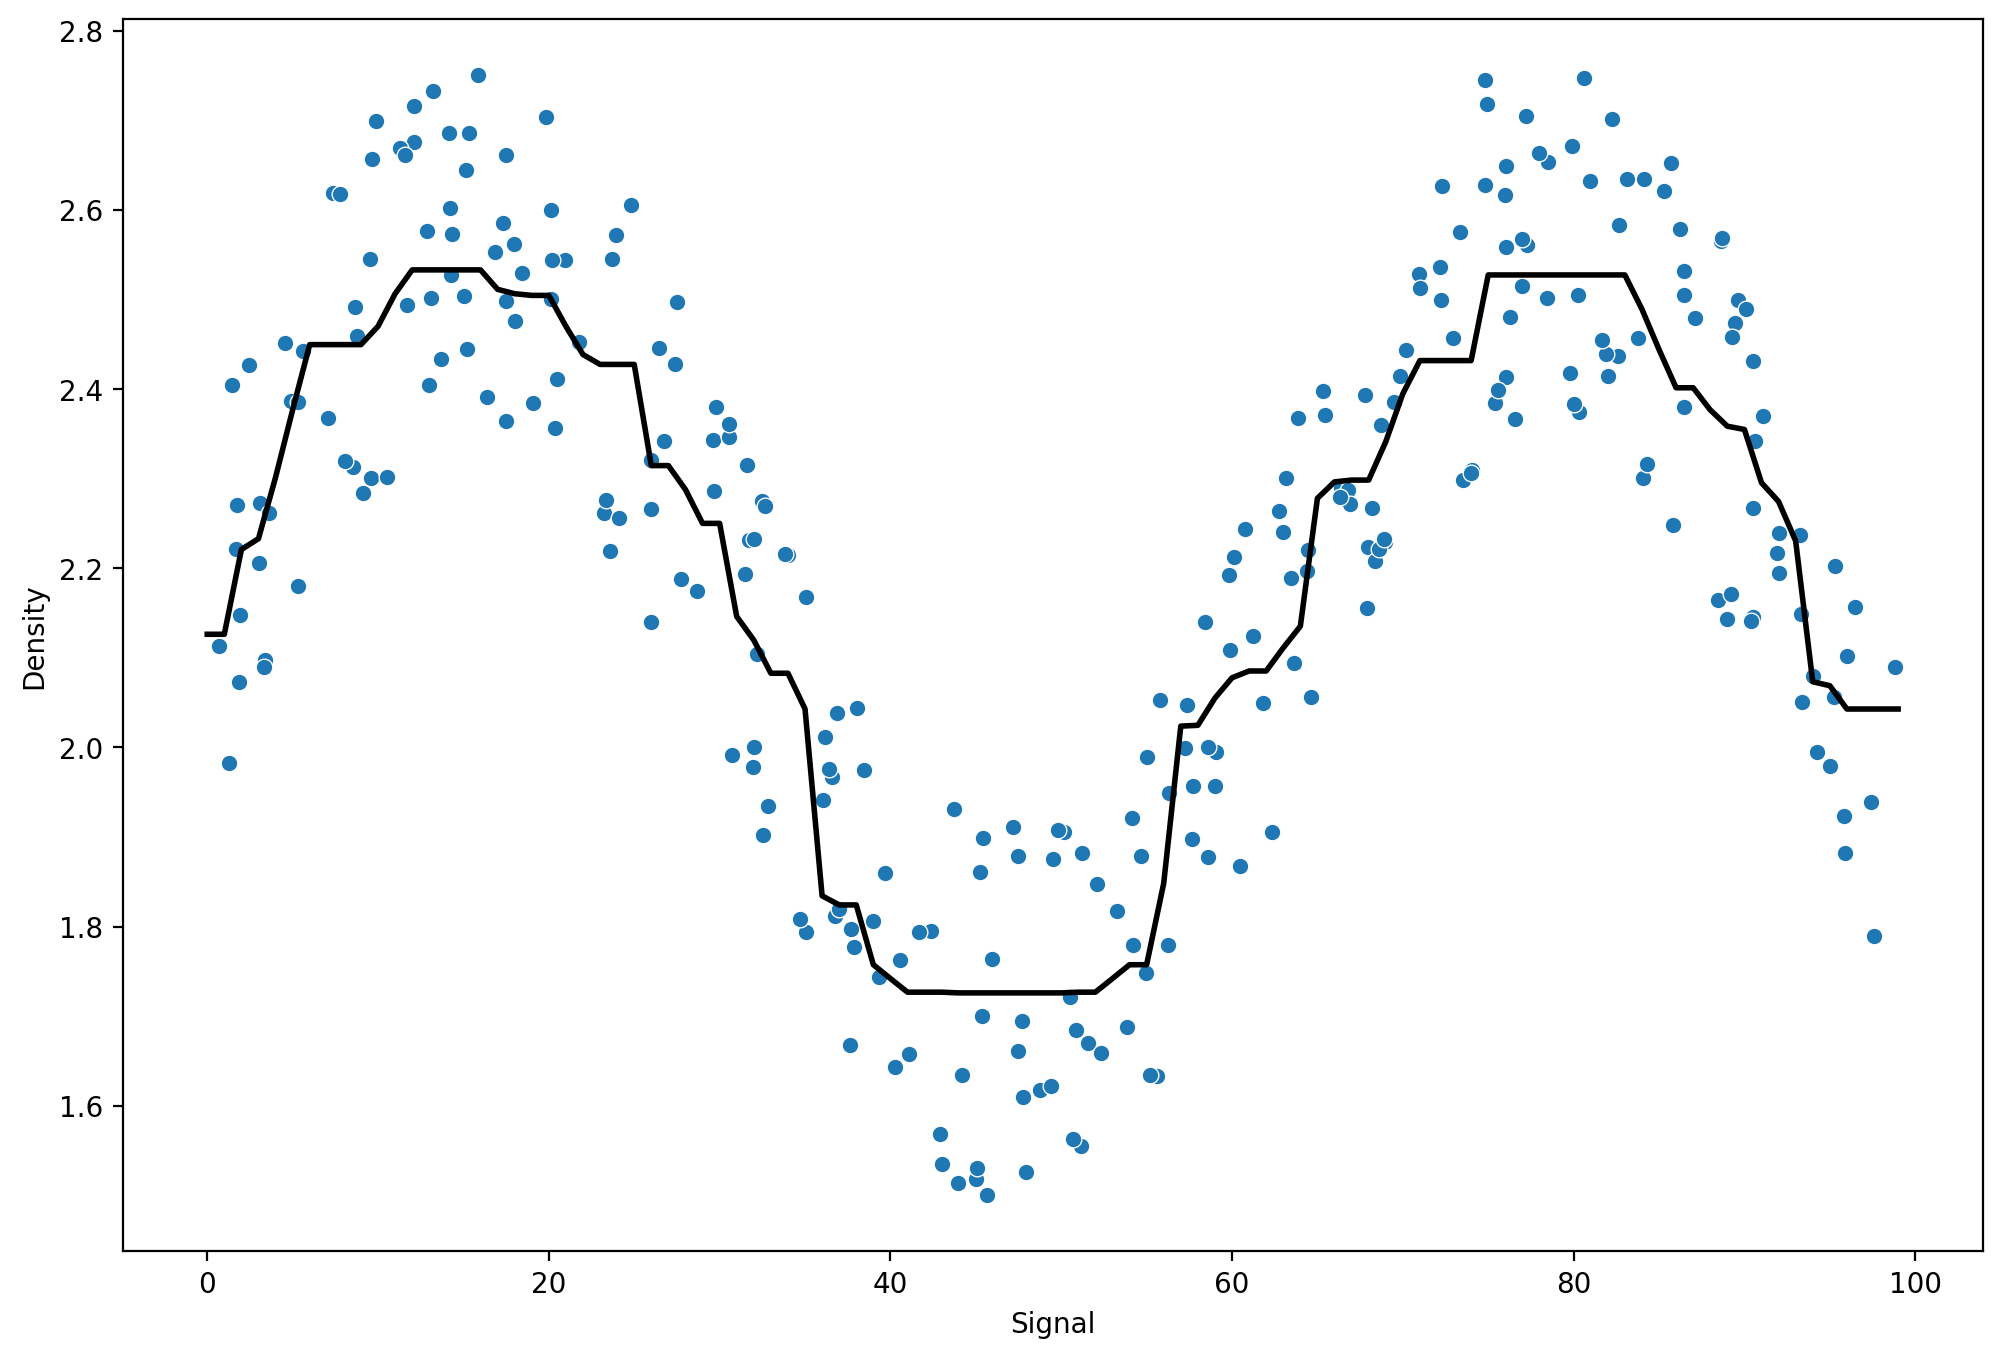

In [98]:
model = AdaBoostRegressor()
run_model(model, X_train, y_train, X_test, y_test)